# Lab #03: 인공지능을 위한 기초 수학 (Basic Mathematics for AI)

**딥러닝 응용 (Deep Learning Application)**  
국립금오공과대학교 산업·빅데이터공학부 | 추상현 교수

---

## 목차

| 파트 | 주제 | 내용 |
|:---:|:---|:---|
| **Part 1** | 확률과 통계 | 확률, 조건부 확률, 베이즈 정리, 확률분포, 선형 회귀 |
| **Part 2** | 선형대수 | 벡터, 선형결합, 내적/외적, 행렬, 고유값/고유벡터 |
| **Part 3** | 미분 | 미분, 편미분, 미분 규칙, 연쇄법칙 |

> **학습 목표:** 각 수학 개념을 Python/PyTorch로 직접 구현하고, 이 개념들이 **인공지능/딥러닝에서 어떻게 활용되는지** 체험합니다.

---
# Part 1: Probability and Statistics (확률과 통계)
---

## 1.1 확률 (Probability)

### 확률과 AI의 관계

- **통계적 분석**: 입력 → 출력 관계를 **사람이 직접 설계**합니다.
- **인공지능(AI)**: 입력 + 출력 데이터를 넣으면 **학습 알고리즘이 관계를 스스로 찾아냅니다.**

확률은 이 두 접근법 모두의 수학적 기반입니다.

### 기본 용어 (Basic Terminology)

| 용어 | 설명 | 예시 |
|:---|:---|:---|
| **시행** | 결과가 우연에 의해 결정되는 실험 | 주사위 던지기 |
| **표본공간** ($\Omega$ 또는 $S$) | 모든 가능한 결과의 집합 | $\{1, 2, 3, 4, 5, 6\}$ |
| **근원사건** | 더 이상 분해할 수 없는 기본 결과 | $\{3\}$ |
| **사건** | 표본공간의 부분집합 | 짝수 = $\{2, 4, 6\}$ |
| **합사건** ($A \cup B$) | A 또는 B가 발생 | |
| **곱사건** ($A \cap B$) | A와 B가 동시에 발생 | |
| **여사건** ($A^c$) | A가 발생하지 않음 | |
| **배반사건** | $A \cap B = \emptyset$ | 홀수와 짝수 |

### 확률의 표현

$$P(A) = \frac{n(A)}{n(S)}$$

### 확률의 성질

- $0 \leq P(A) \leq 1$
- $P(S) = 1$
- $P(\emptyset) = 0$

In [1]:
# 주사위 확률 계산 예제
# Example: Computing probability using Python sets

sample_space = set(range(1, 7))  # {1, 2, 3, 4, 5, 6}
event_even = {x for x in sample_space if x % 2 == 0}  # 짝수 사건
event_ge4 = {x for x in sample_space if x >= 4}  # 4 이상 사건

p_even = len(event_even) / len(sample_space)
p_ge4 = len(event_ge4) / len(sample_space)

# 합사건: A ∪ B
p_union = len(event_even | event_ge4) / len(sample_space)

# 곱사건: A ∩ B
p_intersection = len(event_even & event_ge4) / len(sample_space)

print(f"표본공간 S = {sample_space}")
print(f"짝수 사건 A = {event_even}")
print(f"4 이상 사건 B = {event_ge4}")
print(f"\nP(짝수) = {len(event_even)}/{len(sample_space)} = {p_even:.4f}")
print(f"P(4이상) = {len(event_ge4)}/{len(sample_space)} = {p_ge4:.4f}")
print(f"P(A ∪ B) = {len(event_even | event_ge4)}/{len(sample_space)} = {p_union:.4f}")
print(f"P(A ∩ B) = {len(event_even & event_ge4)}/{len(sample_space)} = {p_intersection:.4f}")

표본공간 S = {1, 2, 3, 4, 5, 6}
짝수 사건 A = {2, 4, 6}
4 이상 사건 B = {4, 5, 6}

P(짝수) = 3/6 = 0.5000
P(4이상) = 3/6 = 0.5000
P(A ∪ B) = 4/6 = 0.6667
P(A ∩ B) = 2/6 = 0.3333


### 🔗 AI 연결: 확률 → Softmax (신경망의 출력을 확률로 변환)

신경망의 마지막 층은 각 클래스에 대한 점수(logit)를 출력합니다. 이 점수는 아직 확률이 아닙니다.

**Softmax 함수**가 이 점수들을 확률의 조건(0~1 사이, 합=1)을 만족하도록 변환합니다.

$$\text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}}$$

- 예: 이미지 분류에서 "이 사진이 고양이일 확률 70%, 개일 확률 20%, 새일 확률 10%"
- 즉, **확률의 기본 성질**이 바로 Softmax의 설계 원리입니다!

In [2]:
import torch

# 신경망이 출력한 점수 (logits) — 아직 확률이 아님
logits = torch.tensor([2.0, 1.0, 0.1])
labels = ["고양이", "개", "새"]

# Softmax로 확률 변환
probs = torch.softmax(logits, dim=0)

print("=== Softmax: 신경망 출력을 확률로 변환 ===\n")
print("신경망 출력 (logits):")
for label, logit in zip(labels, logits):
    print(f"  {label}: {logit:.1f}")

print(f"\nSoftmax 적용 후 (확률):")
for label, p in zip(labels, probs):
    bar = "█" * int(p * 30)
    print(f"  {label}: {p:.3f} ({p*100:.1f}%) {bar}")

print(f"\n확률의 합 = {probs.sum():.3f} (항상 1)")
print("\n→ 확률의 조건 (0≤P≤1, 합=1)이 Softmax의 설계 원리!")

=== Softmax: 신경망 출력을 확률로 변환 ===

신경망 출력 (logits):
  고양이: 2.0
  개: 1.0
  새: 0.1

Softmax 적용 후 (확률):
  고양이: 0.659 (65.9%) ███████████████████
  개: 0.242 (24.2%) ███████
  새: 0.099 (9.9%) ██

확률의 합 = 1.000 (항상 1)

→ 확률의 조건 (0≤P≤1, 합=1)이 Softmax의 설계 원리!


### 실습 1-1 [초급] 확률 기본 계산

**문제:** 카드 한 벌(52장)에서 카드 1장을 뽑을 때, 다음 확률을 Python으로 계산하세요.

1. 하트(Heart)를 뽑을 확률 — 하트는 13장
2. 킹(King)을 뽑을 확률 — 킹은 4장
3. 하트 **또는** 킹을 뽑을 확률 (합사건 $A \cup B$)
4. 하트**이면서** 킹을 뽑을 확률 (곱사건 $A \cap B$)

> **힌트:** $P(A \cup B) = P(A) + P(B) - P(A \cap B)$

In [5]:
# 실습 1-1: 빈칸을 채우세요

total_cards = 52

# 1. P(Heart) — 하트는 13장
n_hearts = 13
p_heart = n_hearts / total_cards
print(f"P(Heart) = {n_hearts}/{total_cards} = {p_heart:.4f}")

# 2. P(King) — 킹은 4장
n_kings = 4
p_king = n_kings / total_cards
print(f"P(King) = {n_kings}/{total_cards} = {p_king:.4f}")

# 3. P(Heart ∪ King) = P(Heart) + P(King) - P(Heart ∩ King)
n_heart_and_king = n_hearts + n_kings  # 하트이면서 킹인 카드는 몇 장?
p_union = p_heart + p_king - (1 / total_cards)
print(f"P(Heart ∪ King) = {p_union:.4f}")

# 4. P(Heart ∩ King)
p_intersection = 1 / total_cards
print(f"P(Heart ∩ King) = {p_intersection:.4f}")

# 검증
assert abs(p_heart - 13/52) < 1e-6, "P(Heart) 오답"
assert abs(p_king - 4/52) < 1e-6, "P(King) 오답"
assert abs(p_union - 16/52) < 1e-6, "P(Heart ∪ King) 오답"
assert abs(p_intersection - 1/52) < 1e-6, "P(Heart ∩ King) 오답"
print("\n✅ 모든 테스트 통과!")

P(Heart) = 13/52 = 0.2500
P(King) = 4/52 = 0.0769
P(Heart ∪ King) = 0.3077
P(Heart ∩ King) = 0.0192

✅ 모든 테스트 통과!


## 1.2 조건부 확률 (Conditional Probability)

### 정의

어떤 사건 $A$가 발생했다는 **조건 하에** 사건 $B$가 발생할 확률:

$$P(B|A) = \frac{P(A \cap B)}{P(A)}$$

### 독립 사건 vs 종속 사건

- **독립 사건**: $P(B|A) = P(B|A^c) = P(B)$ → $P(A \cap B) = P(A)P(B)$
  - 한 사건의 발생이 다른 사건의 확률에 영향을 주지 않음
- **종속 사건**: $P(B|A) \neq P(B|A^c) \neq P(B)$
  - 한 사건의 발생이 다른 사건의 확률에 영향을 줌

### 예제 (비복원 추출)

가방에 빨간 공 3개, 파란 공 2개가 있습니다.  
비복원 추출로 2개를 뽑을 때, **두 번째가 파란 공일 때 첫 번째가 빨간 공이었을 확률**은?

$$P(B) = P(B|A)P(A) + P(B|A')P(A') = \frac{2}{4}\cdot\frac{3}{5} + \frac{1}{4}\cdot\frac{2}{5} = \frac{6}{20}+\frac{2}{20} = \frac{8}{20} = \frac{2}{5}$$

$$P(A|B) = \frac{P(A \cap B)}{P(B)} = \frac{(3/5)(2/4)}{2/5} = \frac{6/20}{8/20} = \frac{6}{8} = \frac{3}{4}$$

실제로는 전체 확률의 법칙을 사용하여 $P(B)$를 계산해야 합니다.

In [6]:
# 조건부 확률 예제: 가방에 빨간 공 3개, 파란 공 2개 (비복원 추출)
# 두 번째가 파란 공(B)일 때, 첫 번째가 빨간 공(A)이었을 확률 P(A|B)

# 전체 공의 수
red, blue = 3, 2
total = red + blue  # 5

# P(A): 첫 번째에 빨간 공을 뽑을 확률
p_A = red / total
print(f"P(A) = P(첫 번째 빨간) = {red}/{total} = {p_A:.4f}")

# P(B|A): 첫 번째가 빨간이었을 때, 두 번째가 파란일 확률
# 빨간 1개를 이미 뺐으므로 남은 공: 빨간 2, 파란 2 → 총 4개
p_B_given_A = blue / (total - 1)
print(f"P(B|A) = P(두 번째 파란 | 첫 번째 빨간) = {blue}/{total-1} = {p_B_given_A:.4f}")

# P(A ∩ B) = P(A) × P(B|A)
p_A_and_B = p_A * p_B_given_A
print(f"P(A ∩ B) = {p_A:.4f} × {p_B_given_A:.4f} = {p_A_and_B:.4f}")

# P(B): 두 번째가 파란 공일 확률 (전체 확률의 법칙)
# P(B) = P(B|A)P(A) + P(B|A')P(A')
p_Ac = 1 - p_A  # 첫 번째가 파란
p_B_given_Ac = (blue - 1) / (total - 1)  # 파란 1개 빼고 남은 파란 / 나머지
p_B = p_B_given_A * p_A + p_B_given_Ac * p_Ac
print(f"\nP(B) = P(B|A)P(A) + P(B|A')P(A')")
print(f"     = {p_B_given_A:.4f}×{p_A:.4f} + {p_B_given_Ac:.4f}×{p_Ac:.4f}")
print(f"     = {p_B:.4f}")

# P(A|B) = P(A ∩ B) / P(B)
p_A_given_B = p_A_and_B / p_B
print(f"\nP(A|B) = P(A ∩ B) / P(B) = {p_A_and_B:.4f} / {p_B:.4f} = {p_A_given_B:.4f}")
print(f"\n→ 두 번째가 파란 공일 때, 첫 번째가 빨간 공이었을 확률 = {p_A_given_B:.4f}")

P(A) = P(첫 번째 빨간) = 3/5 = 0.6000
P(B|A) = P(두 번째 파란 | 첫 번째 빨간) = 2/4 = 0.5000
P(A ∩ B) = 0.6000 × 0.5000 = 0.3000

P(B) = P(B|A)P(A) + P(B|A')P(A')
     = 0.5000×0.6000 + 0.2500×0.4000
     = 0.4000

P(A|B) = P(A ∩ B) / P(B) = 0.3000 / 0.4000 = 0.7500

→ 두 번째가 파란 공일 때, 첫 번째가 빨간 공이었을 확률 = 0.7500


### 🔗 AI 연결: 조건부 확률 → 나이브 베이즈 스팸 필터

스팸 필터는 "이 단어가 포함된 이메일이 스팸일 확률"을 조건부 확률로 계산합니다.

- $P(\text{스팸}|\text{"무료"})$ = "무료"라는 단어가 있을 때 스팸일 확률
- **나이브 베이즈**는 각 단어의 조건부 확률을 **독립이라고 가정**하고 곱해서 최종 판단합니다.
- 간단하지만 실전에서도 놀라울 정도로 잘 작동하는 분류기입니다!

In [1]:
# 🔗 나이브 베이즈 스팸 필터 — 조건부 확률의 실제 활용

# 학습 데이터에서 얻은 조건부 확률
p_word_given_spam   = {"무료": 0.8, "당첨": 0.7, "회의": 0.1, "보고서": 0.05}
p_word_given_normal = {"무료": 0.1, "당첨": 0.05, "회의": 0.6, "보고서": 0.5}
p_spam = 0.3  # 사전 확률: 전체 이메일 중 30%가 스팸

# 테스트할 이메일들
test_emails = [
    ["무료", "당첨"],       # 스팸스러운 이메일
    ["회의", "보고서"],     # 정상 이메일
]

print("=== 나이브 베이즈 스팸 필터 ===\n")
for email_words in test_emails:
    # 각 단어의 조건부 확률을 곱함 (나이브 = 독립 가정)
    score_spam = p_spam
    score_normal = 1 - p_spam
    for w in email_words:
        score_spam *= p_word_given_spam[w]
        score_normal *= p_word_given_normal[w]

    # 정규화하여 확률로 변환
    prob_spam = score_spam / (score_spam + score_normal)

    result = "🚨 스팸!" if prob_spam > 0.5 else "✉️ 정상"
    print(f"이메일 단어: {email_words}")
    print(f"  P(스팸|단어들) = {prob_spam:.3f} → {result}")
    print()

print("→ 조건부 확률로 이메일을 자동 분류할 수 있다!")

=== 나이브 베이즈 스팸 필터 ===

이메일 단어: ['무료', '당첨']
  P(스팸|단어들) = 0.980 → 🚨 스팸!

이메일 단어: ['회의', '보고서']
  P(스팸|단어들) = 0.007 → ✉️ 정상

→ 조건부 확률로 이메일을 자동 분류할 수 있다!


### 실습 1-2 [초급] 조건부 확률 계산

**문제:** 가방 안에 빨간 공 4개와 파란 공 6개가 있습니다.  
공을 교체하지 않고(비복원) 2개를 뽑을 때, 다음을 계산하세요.

1. 첫 번째에 빨간 공을 뽑을 확률 $P(A)$
2. 첫 번째에 빨간 공을 뽑았을 때, 두 번째에도 빨간 공을 뽑을 조건부 확률 $P(B|A)$
3. 두 공 모두 빨간 공일 확률 $P(A \cap B) = P(A) \times P(B|A)$

In [2]:
# 실습 1-2: 빈칸을 채우세요

red_balls = 4
blue_balls = 6
total_balls = red_balls + blue_balls  # 10

# 1. P(A): 첫 번째에 빨간 공을 뽑을 확률
p_A = red_balls / total_balls
print(f"P(A) = {p_A:.4f}")

# 2. P(B|A): 첫 번째가 빨간이었을 때, 두 번째도 빨간일 조건부 확률
# 빨간 1개를 이미 뺐으므로 남은 빨간 공 = 3, 전체 남은 공 = 9
p_B_given_A = (red_balls - 1) / (total_balls - 1)
print(f"P(B|A) = {p_B_given_A:.4f}")

# 3. P(A ∩ B) = P(A) × P(B|A)
p_both_red = p_A * p_B_given_A
print(f"P(A ∩ B) = P(두 공 모두 빨간) = {p_both_red:.4f}")

# 검증
assert abs(p_A - 4/10) < 1e-6, "P(A) 오답"
assert abs(p_B_given_A - 3/9) < 1e-6, "P(B|A) 오답"
assert abs(p_both_red - 12/90) < 1e-6, "P(A ∩ B) 오답"
print("\n✅ 모든 테스트 통과!")

P(A) = 0.4000
P(B|A) = 0.3333
P(A ∩ B) = P(두 공 모두 빨간) = 0.1333

✅ 모든 테스트 통과!


## 1.3 베이즈 정리 (Bayes' Theorem)

### 빈도주의 vs 베이지안 확률

| | 빈도주의 (Frequentist) | 베이지안 (Bayesian) |
|:---|:---|:---|
| **확률의 의미** | 반복 실험에서의 상대 빈도 | 불확실성에 대한 **믿음(belief)**의 정도 |
| **관점** | 데이터가 랜덤, 파라미터는 고정 | 파라미터가 랜덤, 데이터는 고정 |
| **업데이트** | 새 데이터 → 새 실험 | 새 데이터 → 기존 믿음 **업데이트** |

### 베이즈 공식

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

| 기호 | 이름 | 의미 |
|:---:|:---|:---|
| $P(A)$ | **사전확률** (Prior) | 데이터 관찰 전 A의 확률 |
| $P(B|A)$ | **가능도** (Likelihood) | A가 참일 때 B가 관찰될 확률 |
| $P(A|B)$ | **사후확률** (Posterior) | B를 관찰한 후 A의 확률 |
| $P(B)$ | **주변확률** (Marginal) | B의 전체 확률 |

### 전체 확률의 법칙을 이용한 전개

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B|A) \cdot P(A) + P(B|A') \cdot P(A')}$$

### 예제: DL 수강생의 성별

100명의 학급에서:
- 여학생 30% 중 6%가 Deep Learning 수강
- 남학생 70% 중 10%가 Deep Learning 수강

임의로 뽑은 1명이 DL 수강생일 때, 이 학생이 여학생일 확률은?

$$P(\text{여}|\text{수강}) = \frac{0.06 \times 0.3}{0.06 \times 0.3 + 0.1 \times 0.7} = \frac{0.018}{0.088} \approx 0.2045$$

In [3]:
# 베이즈 정리 예제: DL 수강생의 성별 추정

# 주어진 정보
p_female = 0.3          # P(여학생)
p_male = 0.7            # P(남학생)
p_dl_given_female = 0.06  # P(수강|여학생)
p_dl_given_male = 0.10    # P(수강|남학생)

# Step 1: P(수강) — 전체 확률의 법칙
p_dl = p_dl_given_female * p_female + p_dl_given_male * p_male
print(f"Step 1: P(수강) = P(수강|여)×P(여) + P(수강|남)×P(남)")
print(f"       = {p_dl_given_female}×{p_female} + {p_dl_given_male}×{p_male}")
print(f"       = {p_dl_given_female * p_female} + {p_dl_given_male * p_male}")
print(f"       = {p_dl:.4f}")

# Step 2: 베이즈 정리
p_female_given_dl = (p_dl_given_female * p_female) / p_dl
print(f"\nStep 2: P(여학생|수강) = P(수강|여)×P(여) / P(수강)")
print(f"       = {p_dl_given_female * p_female} / {p_dl:.4f}")
print(f"       = {p_female_given_dl:.4f}")

print(f"\n→ DL 수강생이 여학생일 확률: 약 {p_female_given_dl*100:.1f}%")
print(f"→ 여학생 비율은 30%이지만, DL 수강생 중에서는 약 {p_female_given_dl*100:.1f}%")

Step 1: P(수강) = P(수강|여)×P(여) + P(수강|남)×P(남)
       = 0.06×0.3 + 0.1×0.7
       = 0.018 + 0.06999999999999999
       = 0.0880

Step 2: P(여학생|수강) = P(수강|여)×P(여) / P(수강)
       = 0.018 / 0.0880
       = 0.2045

→ DL 수강생이 여학생일 확률: 약 20.5%
→ 여학생 비율은 30%이지만, DL 수강생 중에서는 약 20.5%


### 🔗 AI 연결: 베이즈 정리 → 데이터로 믿음(belief) 업데이트

베이즈 정리의 핵심: **새로운 데이터(증거)를 관찰할 때마다 기존의 믿음(사전확률)을 업데이트**합니다.

머신러닝에서의 의미:
- 모델이 데이터를 볼수록 점점 더 정확해지는 원리가 바로 베이지안 업데이트입니다.
- 예시: 동전이 공정한지 편향된지 판단 — 던질수록 확신이 강해집니다.

=== 베이지안 추론: 동전 공정성 판단 ===

  1번째 던지기: 앞면 → P(공정) = 0.417, P(편향) = 0.583
  2번째 던지기: 앞면 → P(공정) = 0.338, P(편향) = 0.662
  3번째 던지기: 앞면 → P(공정) = 0.267, P(편향) = 0.733
  4번째 던지기: 뒷면 → P(공정) = 0.378, P(편향) = 0.622
  5번째 던지기: 앞면 → P(공정) = 0.303, P(편향) = 0.697
  6번째 던지기: 앞면 → P(공정) = 0.237, P(편향) = 0.763
  7번째 던지기: 뒷면 → P(공정) = 0.341, P(편향) = 0.659
  8번째 던지기: 앞면 → P(공정) = 0.269, P(편향) = 0.731
  9번째 던지기: 앞면 → P(공정) = 0.209, P(편향) = 0.791
  10번째 던지기: 앞면 → P(공정) = 0.158, P(편향) = 0.842


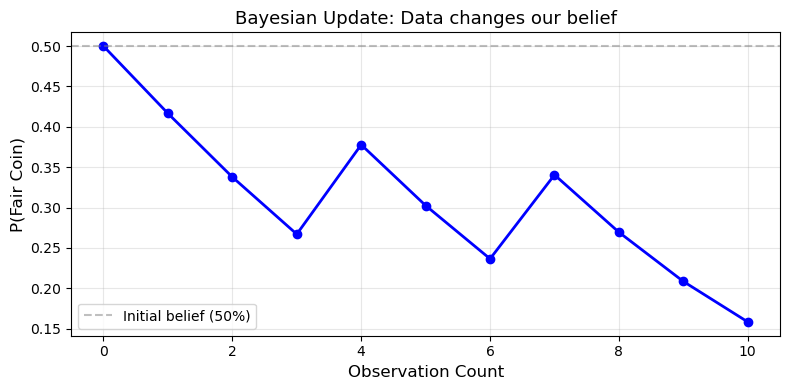


→ 데이터가 쌓일수록 믿음(확률)이 업데이트된다!
→ 이것이 머신러닝에서 '학습'의 수학적 원리입니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 🔗 베이지안 추론: 동전 던지기로 공정성 판단

# 사전 확률: 공정(50%) vs 편향(50%)
prior_fair = 0.5
prior_biased = 0.5

# 데이터를 하나씩 관찰하며 사후 확률 업데이트
observations = [1, 1, 1, 0, 1, 1, 0, 1, 1, 1]  # 1=앞면, 0=뒷면

fair_probs = [prior_fair]
current_fair = prior_fair
current_biased = prior_biased

print("=== 베이지안 추론: 동전 공정성 판단 ===\n")
for i, obs in enumerate(observations):
    # 가능도 계산
    like_fair = 0.5  # 공정한 동전에서 앞면/뒷면 확률
    like_biased = 0.7 if obs == 1 else 0.3  # 편향 동전(앞면 70%)

    # 베이즈 업데이트
    post_fair = like_fair * current_fair
    post_biased = like_biased * current_biased
    total = post_fair + post_biased

    current_fair = post_fair / total
    current_biased = post_biased / total
    fair_probs.append(current_fair)

    result = "앞면" if obs == 1 else "뒷면"
    print(f"  {i+1}번째 던지기: {result} → P(공정) = {current_fair:.3f}, P(편향) = {current_biased:.3f}")

# 시각화
plt.figure(figsize=(8, 4))
plt.plot(range(len(fair_probs)), fair_probs, 'b-o', linewidth=2, markersize=6)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Initial belief (50%)')
plt.xlabel('Observation Count', fontsize=12)
plt.ylabel('P(Fair Coin)', fontsize=12)
plt.title('Bayesian Update: Data changes our belief', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n→ 데이터가 쌓일수록 믿음(확률)이 업데이트된다!")
print("→ 이것이 머신러닝에서 '학습'의 수학적 원리입니다.")

### 실습 1-3 [중급] 베이즈 정리 구현

**문제:** 슬라이드의 예제를 직접 코드로 구현하세요.

한 학급에 학생이 100명 있습니다.
- 여학생 30% 중 6%가 Deep Learning 수업을 수강합니다.
- 남학생 70% 중 10%가 Deep Learning 수업을 수강합니다.

**임의로 뽑은 1명이 DL 수업을 수강할 때, 이 학생이 여학생일 확률을 구하세요.**

$$P(\text{여학생}|\text{수강}) = \frac{P(\text{수강}|\text{여학생}) \times P(\text{여학생})}{P(\text{수강}|\text{여학생}) \times P(\text{여학생}) + P(\text{수강}|\text{남학생}) \times P(\text{남학생})}$$

In [ ]:
# 실습 1-3: 빈칸을 채우세요

# 주어진 정보
p_female = ____          # P(여학생) = 0.3
p_male = ____            # P(남학생) = 0.7
p_dl_given_female = ____ # P(수강|여학생) = 0.06
p_dl_given_male = ____   # P(수강|남학생) = 0.1

# Step 1: P(수강) 계산 — 전체 확률의 법칙
# P(수강) = P(수강|여학생)×P(여학생) + P(수강|남학생)×P(남학생)
p_dl = ____

print(f"P(수강) = {p_dl:.4f}")

# Step 2: 베이즈 정리 적용
# P(여학생|수강) = P(수강|여학생) × P(여학생) / P(수강)
p_female_given_dl = ____

print(f"P(여학생|수강) = {p_female_given_dl:.4f}")

# 검증 (기대값: 약 0.2045)
expected = 0.3 * 0.06 / (0.3 * 0.06 + 0.7 * 0.1)
assert abs(p_female_given_dl - expected) < 1e-4, "오답"
print(f"\n✅ 테스트 통과! (기대값: {expected:.4f})")

## 1.4 통계 — 확률 변수와 확률 분포

### 확률 변수 (Random Variable)

랜덤한 결과를 **수치로 표현**하는 변수입니다.

| 종류 | 설명 | 예시 |
|:---|:---|:---|
| **이산 (Discrete)** | 셀 수 있는 값 | 동전 앞면 수, 주사위 눈 |
| **연속 (Continuous)** | 구간의 모든 값 | 온도, 키, 대기 시간 |

### 확률 함수

- **PMF** (확률 질량 함수, 이산): $f(x) = P[X = x]$
  - 조건: $f(x) \geq 0$, $\sum_x f(x) = 1$
- **PDF** (확률 밀도 함수, 연속): $f(x) \geq 0$, $\int_{-\infty}^{\infty} f(x)dx = 1$
  - 주의: $f(x)$는 확률이 아니라 **밀도**입니다. 확률은 $P(a \leq X \leq b) = \int_a^b f(x)dx$

### 주요 확률분포

| 분포 | 종류 | 용도 | AI 활용 |
|:---|:---:|:---|:---|
| **이항분포** | 이산 | n번 시행에서 성공 횟수 | 이진 분류 |
| **균등분포** | 연속 | 모든 값이 동일한 확률 | 랜덤 초기화 |
| **포아송분포** | 이산 | 단위 시간당 사건 발생 횟수 | 이벤트 모델링 |
| **정규분포** | 연속 | 자연현상의 기본 분포 | 가중치 초기화, 노이즈 |
| **카이제곱분포** | 연속 | 적합도 검정 | 통계적 검정 |

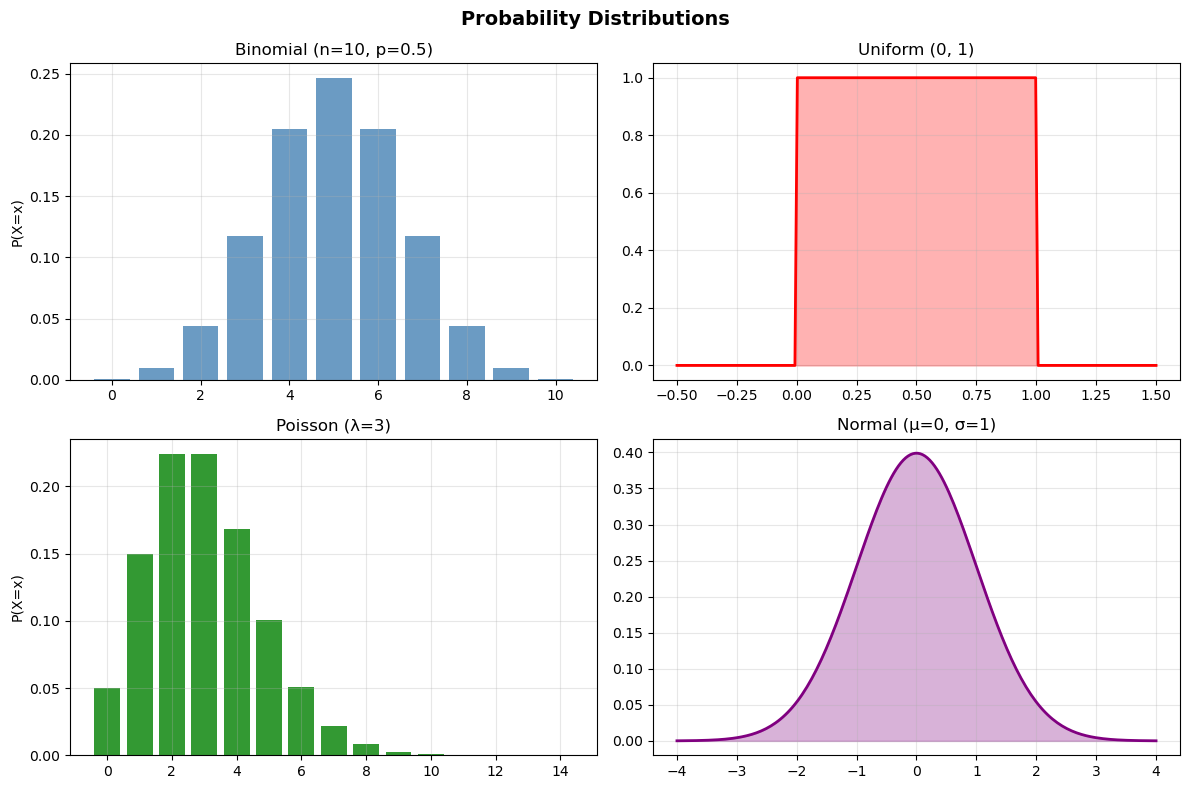

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Binomial (이항분포) — PMF
n, p = 10, 0.5
x_binom = np.arange(0, n+1)
axes[0, 0].bar(x_binom, stats.binom.pmf(x_binom, n, p), color='steelblue', alpha=0.8)
axes[0, 0].set_title(f'Binomial (n={n}, p={p})', fontsize=12)
axes[0, 0].set_ylabel('P(X=x)')

# 2. Uniform (균등분포) — PDF
x_unif = np.linspace(-0.5, 1.5, 200)
axes[0, 1].plot(x_unif, stats.uniform.pdf(x_unif, 0, 1), 'r-', linewidth=2)
axes[0, 1].fill_between(x_unif, stats.uniform.pdf(x_unif, 0, 1), alpha=0.3, color='red')
axes[0, 1].set_title('Uniform (0, 1)', fontsize=12)

# 3. Poisson (포아송분포) — PMF
lam = 3
x_pois = np.arange(0, 15)
axes[1, 0].bar(x_pois, stats.poisson.pmf(x_pois, lam), color='green', alpha=0.8)
axes[1, 0].set_title(f'Poisson (λ={lam})', fontsize=12)
axes[1, 0].set_ylabel('P(X=x)')

# 4. Normal (정규분포) — PDF
x_norm = np.linspace(-4, 4, 200)
axes[1, 1].plot(x_norm, stats.norm.pdf(x_norm, 0, 1), 'purple', linewidth=2)
axes[1, 1].fill_between(x_norm, stats.norm.pdf(x_norm, 0, 1), alpha=0.3, color='purple')
axes[1, 1].set_title('Normal (μ=0, σ=1)', fontsize=12)

for ax in axes.flat:
    ax.grid(True, alpha=0.3)
plt.suptitle('Probability Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔗 AI 연결: 확률분포 → 가중치 초기화 & 드롭아웃

- **정규분포(가우시안)**: 신경망의 가중치를 초기화할 때 사용합니다. 너무 크거나 작은 초기값은 학습을 불안정하게 만들므로, 평균 0, 작은 분산의 정규분포에서 샘플링합니다.
- **베르누이 분포**: 드롭아웃(Dropout)에서 사용합니다. 학습 중 각 뉴런을 확률 $p$로 끄는(0으로 만드는) 기법으로, 과적합을 방지합니다.
- 즉, **확률분포의 이해 없이는 신경망을 제대로 설계할 수 없습니다!**

=== 확률분포의 AI 활용 ===

[정규분포 초기화]
  평균: -0.0003 (≈ 0)
  표준편차: 0.0098 (≈ 0.01)

[드롭아웃 (p=0.5)]
  원래 활성값:  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  드롭아웃 후: [2.0, 0.0, 0.0, 0.0, 2.0, 0.0, 2.0, 0.0, 0.0, 0.0]
  → 약 50%의 뉴런이 랜덤으로 비활성화!


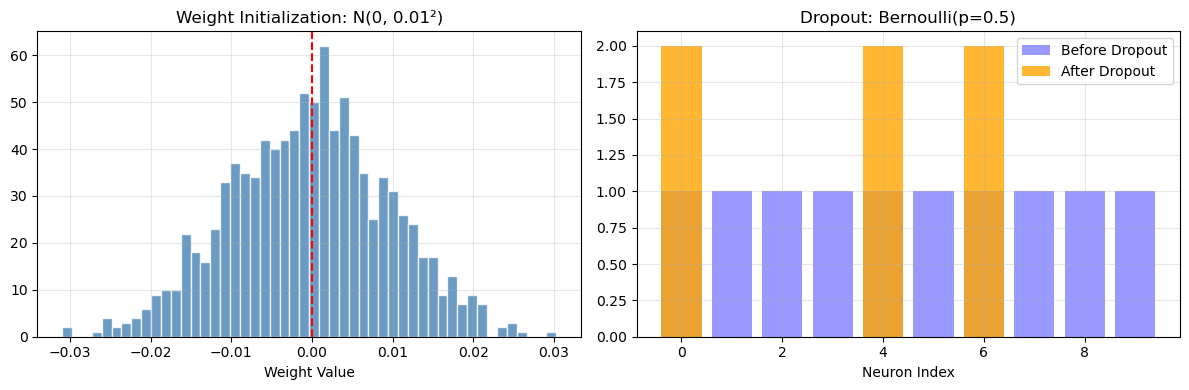

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print("=== 확률분포의 AI 활용 ===\n")

# (1) 정규분포로 가중치 초기화
weights = torch.randn(1000) * 0.01  # N(0, 0.01²)
print(f"[정규분포 초기화]")
print(f"  평균: {weights.mean():.4f} (≈ 0)")
print(f"  표준편차: {weights.std():.4f} (≈ 0.01)")

# (2) 드롭아웃: 베르누이 분포
dropout = nn.Dropout(p=0.5)
activations = torch.ones(10)
dropped = dropout(activations)
# 참고: PyTorch Dropout은 살아남은 뉴런을 1/(1-p)로 스케일합니다
# p=0.5일 때 살아남은 값이 2.0으로 나타나는 것은 정상입니다 (inverted dropout)

print(f"\n[드롭아웃 (p=0.5)]")
print(f"  원래 활성값:  {activations.tolist()}")
print(f"  드롭아웃 후: {dropped.tolist()}")
print(f"  → 약 50%의 뉴런이 랜덤으로 비활성화!")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(weights.numpy(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Weight Initialization: N(0, 0.01²)', fontsize=12)
axes[0].set_xlabel('Weight Value')
axes[0].axvline(x=0, color='red', linestyle='--')

axes[1].bar(range(10), activations.numpy(), alpha=0.4, label='Before Dropout', color='blue')
axes[1].bar(range(10), dropped.numpy(), alpha=0.8, label='After Dropout', color='orange')
axes[1].set_title('Dropout: Bernoulli(p=0.5)', fontsize=12)
axes[1].set_xlabel('Neuron Index')
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 실습 1-4 [초급] 확률 분포 시각화

**문제:** 다음 확률 분포를 시각화하세요.

1. 이항분포: $n=20, p=0.3$인 PMF를 막대그래프로 그리기
2. 정규분포: $\mu=0, \sigma=1$인 PDF와 $\mu=2, \sigma=0.5$인 PDF를 **같은 그래프**에 그리기

> **힌트:** `scipy.stats.binom.pmf(x, n, p)`, `scipy.stats.norm.pdf(x, mu, sigma)`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 실습 1-4: 빈칸을 채우세요

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. 이항분포 (n=20, p=0.3)
n, p = ____, ____
x_binom = np.arange(0, n+1)
pmf_values = stats.binom.pmf(x_binom, ____, ____)
axes[0].bar(x_binom, pmf_values, color='steelblue', alpha=0.8)
axes[0].set_title(f'Binomial PMF (n={n}, p={p})', fontsize=12)
axes[0].set_xlabel('X')
axes[0].set_ylabel('P(X=x)')

# 2. 정규분포 두 개 비교
x_norm = np.linspace(-4, 6, 300)
pdf1 = stats.norm.pdf(x_norm, ____, ____)  # μ=0, σ=1
pdf2 = stats.norm.pdf(x_norm, ____, ____)  # μ=2, σ=0.5
axes[1].plot(x_norm, pdf1, 'b-', linewidth=2, label='N(0, 1)')
axes[1].plot(x_norm, pdf2, 'r-', linewidth=2, label='N(2, 0.5)')
axes[1].fill_between(x_norm, pdf1, alpha=0.2, color='blue')
axes[1].fill_between(x_norm, pdf2, alpha=0.2, color='red')
axes[1].set_title('Normal PDF Comparison', fontsize=12)
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ 그래프가 정상적으로 출력되면 성공!")

## 1.5 선형 회귀 (Linear Regression)

### 선형 모델

$$y = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n$$

### 단순 선형 회귀 (Simple Linear Regression)

$$Y = \beta_0 + \beta_1 x + \epsilon, \quad \epsilon \sim N(0, \sigma^2)$$

### 최소제곱법 (OLS: Ordinary Least Squares)

목적: 잔차 제곱의 합을 최소화하는 $\beta_0$, $\beta_1$을 찾습니다.

$$\min_{\beta_0, \beta_1} f(\beta_0, \beta_1) = \sum_{i=1}^{n}(y_i - \beta_0 - \beta_1 x_i)^2$$

### OLS 해 (Solution)

$$\hat{\beta}_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

### 적합도 (Goodness of Fit)

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2} = 1 - \frac{SSE}{SST}$$

- $R^2 = 1$: 완벽한 적합
- $R^2 = 0$: 설명력 없음

x̄ = 3.0, ȳ = 77.0

β₁ = Σ(xi-x̄)(yi-ȳ) / Σ(xi-x̄)² = 75.0 / 10.0 = 7.5000
β₀ = ȳ - β₁x̄ = 77.0 - 7.5×3.0 = 54.5000

회귀식: ŷ = 54.5 + 7.5x
R² = 1 - SSE/SST = 1 - 17.50/580.00 = 0.9698


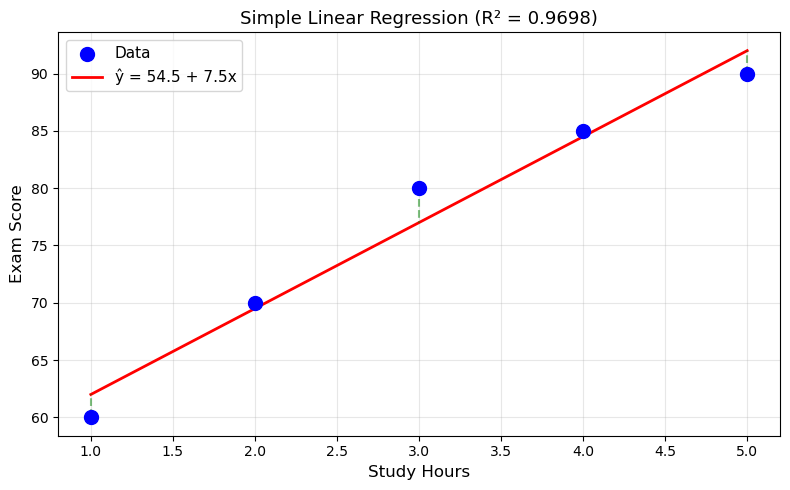

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 선형 회귀 예제: 공부 시간 vs 시험 점수 (슬라이드 27)

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([60, 70, 80, 85, 90], dtype=float)

# 평균 계산
x_mean = np.mean(x)
y_mean = np.mean(y)
print(f"x̄ = {x_mean}, ȳ = {y_mean}")

# β₁ 계산
numerator = np.sum((x - x_mean) * (y - y_mean)) # 분자
denominator = np.sum((x - x_mean) ** 2) # 분모
beta1 = numerator / denominator
print(f"\nβ₁ = Σ(xi-x̄)(yi-ȳ) / Σ(xi-x̄)² = {numerator} / {denominator} = {beta1:.4f}")

# β₀ 계산
beta0 = y_mean - beta1 * x_mean
print(f"β₀ = ȳ - β₁x̄ = {y_mean} - {beta1}×{x_mean} = {beta0:.4f}")

# 예측값
y_hat = beta0 + beta1 * x
print(f"\n회귀식: ŷ = {beta0:.1f} + {beta1:.1f}x")

# R² 계산
SSE = np.sum((y - y_hat) ** 2)
SST = np.sum((y - y_mean) ** 2)
R2 = 1 - SSE / SST
print(f"R² = 1 - SSE/SST = 1 - {SSE:.2f}/{SST:.2f} = {R2:.4f}")

# 시각화
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', s=100, zorder=5, label='Data')
plt.plot(x, y_hat, 'r-', linewidth=2, label=f'ŷ = {beta0:.1f} + {beta1:.1f}x')

# 잔차 표시
for xi, yi, yhi in zip(x, y, y_hat):
    plt.plot([xi, xi], [yi, yhi], 'g--', alpha=0.5)

plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.title(f'Simple Linear Regression (R² = {R2:.4f})', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 🔗 AI 연결: 선형 회귀 = 가장 단순한 신경망 (단일 뉴런)

선형 회귀 $y = wx + b$는 **뉴런 하나짜리 신경망**과 완전히 동일합니다.

- 활성함수 없이 입력에 가중치를 곱하고 편향을 더하는 것이 뉴런의 기본 연산입니다.
- 딥러닝은 이 단순한 연산을 수백만 개 쌓아서 복잡한 패턴을 학습하는 것입니다.
- 아래 코드에서 `nn.Linear(1, 1)`이 정확히 $y = wx + b$를 수행함을 확인하세요!

In [ ]:
import torch
import torch.nn as nn

print("=== 선형 회귀 = 단일 뉴런 (nn.Linear) ===\n")

# 같은 데이터
x = torch.tensor([[1.], [2.], [3.], [4.], [5.]])
y = torch.tensor([[60.], [70.], [80.], [85.], [90.]])

# 단일 뉴런 = 선형 회귀
neuron = nn.Linear(1, 1)  # 입력 1개, 출력 1개 → y = wx + b
optimizer = torch.optim.SGD(neuron.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# 학습
for epoch in range(2000):
    pred = neuron(x)
    loss = loss_fn(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

w = neuron.weight.item()
b = neuron.bias.item()
print(f"  nn.Linear 학습 결과: y = {w:.2f}x + {b:.2f}")
print(f"  OLS 공식 결과:       y = 7.50x + 54.50")
print(f"\n→ 단일 뉴런이 선형 관계를 학습했습니다!")
print(f"→ 딥러닝은 이 뉴런을 수백만 개 연결한 것입니다.")

### 실습 1-5 [초급] OLS로 회귀 계수 직접 계산 + R²

**문제:** 10명의 학생 데이터로 최소제곱법을 직접 구현하세요.

| 공부 시간 (x) | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 시험 점수 (y) | 25 | 35 | 45 | 50 | 62 | 68 | 75 | 82 | 90 | 95 |

1. $\hat{\beta}_1$, $\hat{\beta}_0$ 계산
2. $R^2$ 계산
3. 데이터와 회귀선을 그래프에 표시

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 실습 1-5: 빈칸을 채우세요

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
y = np.array([25, 35, 45, 50, 62, 68, 75, 82, 90, 95], dtype=float)

# Step 1: 평균 계산
x_mean = ____
y_mean = ____

# Step 2: β₁ = Σ(xi - x̄)(yi - ȳ) / Σ(xi - x̄)²
numerator = np.sum(____)     # (xi - x_mean) * (yi - y_mean)
denominator = np.sum(____)   # (xi - x_mean)²
beta1 = ____

# Step 3: β₀ = ȳ - β₁x̄
beta0 = ____

# Step 4: 예측값
y_hat = ____  # beta0 + beta1 * x

# Step 5: R² = 1 - SSE/SST
SSE = np.sum(____)  # (yi - y_hat)²
SST = np.sum(____)  # (yi - y_mean)²
R2 = ____

print(f"β₀ = {beta0:.4f}")
print(f"β₁ = {beta1:.4f}")
print(f"회귀식: ŷ = {beta0:.2f} + {beta1:.2f}x")
print(f"R² = {R2:.4f}")

# 시각화
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', s=80, zorder=5, label='Data')
plt.plot(x, y_hat, 'r-', linewidth=2, label=f'y = {beta0:.2f} + {beta1:.2f}x')
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.title(f'Simple Linear Regression (R² = {R2:.4f})', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 검증
assert abs(beta1 - 7.7636) < 0.01, "β₁ 오답"
assert abs(beta0 - 20.0) < 0.01, "β₀ 오답"
assert R2 > 0.98, "R² 값 확인 필요"
print("\n✅ 모든 테스트 통과!")

### 실습 1-6 [중급] 도전 문제: PyTorch 경사하강법으로 선형 회귀

**문제:** OLS 공식 대신 PyTorch의 경사하강법으로 같은 데이터에 대해 선형 회귀를 수행하세요.  
**최종적으로 OLS 결과(실습 1-5)와 비교하여 동일한 결과가 나오는지 확인합니다.**

**단계별 가이드:**

1. **데이터 준비:** 실습 1-5의 x, y 데이터를 `torch.tensor`로 변환 (`dtype=torch.float32`)
2. **파라미터 초기화:** `beta0`, `beta1`을 0.0으로 초기화 (`requires_grad=True`)
3. **하이퍼파라미터 설정:** `learning_rate = 0.001`, `n_epochs = 5000`
4. **학습 루프 (각 에포크마다):**
   - 예측값 계산: `y_hat = beta0 + beta1 * x`
   - MSE 손실 계산: `loss = torch.mean((y - y_hat) ** 2)`
   - `loss.backward()`로 기울기 계산
   - `torch.no_grad()` 블록에서 파라미터 업데이트: `param -= lr * param.grad`
   - `.grad.zero_()`로 기울기 초기화
5. **결과 시각화:** Loss curve + 회귀선(OLS vs GD 비교)

> **힌트:** 🔗 AI 데모에서 `nn.Linear`로 했던 것과 같은 원리입니다. 이번에는 직접 `backward()`와 파라미터 업데이트를 구현합니다.

In [ ]:
import torch
import matplotlib.pyplot as plt

# 실습 1-6: 빈칸을 채우세요

# Step 1: Data
x_t = torch.tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=torch.float32)
y_t = torch.tensor([25, 35, 45, 50, 62, 68, 75, 82, 90, 95], dtype=torch.float32)

# Step 2: Parameters
beta0_t = torch.tensor(0.0, requires_grad=____)
beta1_t = torch.tensor(0.0, requires_grad=____)

# Step 3: Hyperparameters
learning_rate = ____
n_epochs = ____

# Step 4: Training loop
losses = []
for epoch in range(n_epochs):
    # Forward: prediction
    y_hat_t = ____  # beta0 + beta1 * x

    # Loss: MSE
    loss = ____  # mean((y - y_hat)^2)

    # Backward
    ____  # compute gradients

    # Update parameters
    with torch.no_grad():
        beta0_t -= ____  # lr * gradient
        beta1_t -= ____

    # Reset gradients
    beta0_t.grad.____()
    beta1_t.grad.____()

    losses.append(loss.item())
    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.4f} | β₀: {beta0_t.item():.4f} | β₁: {beta1_t.item():.4f}")

print(f"\n최종 결과: ŷ = {beta0_t.item():.2f} + {beta1_t.item():.2f}x")
print(f"OLS 결과:  ŷ = 20.00 + 7.76x")

# Step 5: Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(losses)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training Loss Curve', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Regression comparison
with torch.no_grad():
    y_pred_gd = beta0_t + beta1_t * x_t
axes[1].scatter(x_t.numpy(), y_t.numpy(), color='blue', s=80, zorder=5, label='Data')
axes[1].plot(x_t.numpy(), y_pred_gd.numpy(), 'r-', linewidth=2,
             label=f'GD: y={beta0_t.item():.2f}+{beta1_t.item():.2f}x')
axes[1].plot(x_t.numpy(), (20.00 + 7.76 * x_t).numpy(), 'g--', linewidth=2,
             label='OLS: y=20.00+7.76x')
axes[1].set_title('Gradient Descent vs OLS', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 검증
assert abs(beta1_t.item() - 7.76) < 0.5, "β₁이 OLS 결과와 크게 다릅니다"
print("\n✅ 경사하강법과 OLS가 같은 결과로 수렴!")
print("→ 이것이 신경망 학습의 기본 원리입니다.")

---
# Part 2: Linear Algebra (선형대수)
---

## 2.1 벡터와 공간 (Vector and Space)

### Tensor 계층

| Name | Notation | Dimension | Python (NumPy) |
|------|----------|-----------|----------------|
| Scalar | $x$ | 0-d | `np.array(3.14)` |
| Vector | $\vec{x}$ | 1-d | `np.array([1, 2, 3])` |
| Matrix | $X$ | 2-d | `np.array([[1,2],[3,4]])` |
| Tensor | $\mathcal{X}$ | 3-d+ | `np.random.randn(2,3,4)` |

Scalar(0-d) $\rightarrow$ Vector(1-d) $\rightarrow$ Matrix(2-d) $\rightarrow$ Tensor(3-d+)

### Vector 정의

- **기하학적 정의**: 크기(magnitude)와 방향(direction)을 가지는 양
- **대수적 정의**: 숫자의 리스트 (ordered list of numbers)

### Vector 표현

- **Row vector**: $\vec{a} = [a_1, a_2, \ldots, a_n]$
- **Column vector**: $\vec{a} = \begin{bmatrix} a_1 \\ a_2 \\ \vdots \\ a_n \end{bmatrix}$
- **Transpose**: $\vec{a}^T$ — row ↔ column 변환

### 벡터의 특성

- 크기와 방향이 같으면 **같은 벡터**입니다.
- 위치는 달라도 됩니다 (자유 벡터, free vector).

In [ ]:
import numpy as np
import torch

print("=== Tensor 계층: NumPy vs PyTorch ===\n")

# --- Scalar (0-d) ---
scalar_np = np.array(3.14)
scalar_pt = torch.tensor(3.14)
print("[Scalar]")
print(f"  NumPy  : value={scalar_np}, shape={scalar_np.shape}, ndim={scalar_np.ndim}, dtype={scalar_np.dtype}")
print(f"  PyTorch: value={scalar_pt}, shape={scalar_pt.shape}, ndim={scalar_pt.ndim}, dtype={scalar_pt.dtype}")

# --- Vector (1-d) ---
vector_np = np.array([1, 2, 3, 4, 5])
vector_pt = torch.tensor([1, 2, 3, 4, 5])
print("\n[Vector]")
print(f"  NumPy  : value={vector_np}, shape={vector_np.shape}, ndim={vector_np.ndim}, dtype={vector_np.dtype}")
print(f"  PyTorch: value={vector_pt}, shape={vector_pt.shape}, ndim={vector_pt.ndim}, dtype={vector_pt.dtype}")

# --- Matrix (2-d) ---
matrix_np = np.array([[1, 2, 3], [4, 5, 6]])
matrix_pt = torch.tensor([[1, 2, 3], [4, 5, 6]])
print("\n[Matrix]")
print(f"  NumPy  : shape={matrix_np.shape}, ndim={matrix_np.ndim}, dtype={matrix_np.dtype}")
print(f"  PyTorch: shape={matrix_pt.shape}, ndim={matrix_pt.ndim}, dtype={matrix_pt.dtype}")

# --- 3D Tensor ---
tensor_np = np.random.randn(2, 3, 4)
tensor_pt = torch.randn(2, 3, 4)
print("\n[3D Tensor]")
print(f"  NumPy  : shape={tensor_np.shape}, ndim={tensor_np.ndim}, dtype={tensor_np.dtype}")
print(f"  PyTorch: shape={tensor_pt.shape}, ndim={tensor_pt.ndim}, dtype={tensor_pt.dtype}")

### 🔗 AI 연결: 벡터 = 데이터 표현 (모든 데이터는 숫자 벡터로!)

AI에서 모든 데이터(텍스트, 이미지, 음성)는 **숫자 벡터**로 변환되어야 합니다.

- **이미지**: 28×28 픽셀 → 784차원 벡터
- **단어**: Word2Vec 임베딩으로 의미를 담은 벡터 (예: king - man + woman ≈ queen)

벡터 연산이 **의미 연산**과 대응한다는 놀라운 성질!

In [ ]:
import torch
import numpy as np

print("=== 벡터 = 데이터 표현 ===\n")

# (1) Word Embedding: 벡터 연산 = 의미 연산
embeddings = {
    "king":   torch.tensor([0.9, 0.1, 0.8, 0.2]),
    "queen":  torch.tensor([0.9, 0.1, 0.2, 0.8]),
    "man":    torch.tensor([0.1, 0.1, 0.8, 0.2]),
    "woman":  torch.tensor([0.1, 0.1, 0.2, 0.8]),
}

result = embeddings["king"] - embeddings["man"] + embeddings["woman"]
print("[Word Embedding]")
print(f"  king - man + woman = {result.tolist()}")
print(f"  queen              = {embeddings['queen'].tolist()}")
print(f"  \u2192 벡터 연산으로 의미 관계를 표현할 수 있다!\n")

# (2) Image as Vector: 28×28 → 784-dim vector
image = torch.randn(28, 28)  # MNIST-like image
image_vector = image.flatten()
print(f"[이미지 \u2192 벡터]")
print(f"  28\u00d728 이미지 \u2192 {image_vector.shape[0]}차원 벡터")
print(f"  \u2192 신경망은 이 벡터를 입력으로 받습니다!")

### 실습 2-1 [초급] 텐서 생성 및 속성 확인

**문제:** NumPy와 PyTorch로 다음을 생성하고 `shape`, `ndim`, `dtype`을 출력하세요.

1. 스칼라: `3.14`
2. 벡터: `[1, 2, 3, 4, 5]`
3. 행렬: `[[1,2,3],[4,5,6]]`
4. 3차원 텐서: shape `(2, 3, 4)`의 랜덤 텐서

In [ ]:
import numpy as np
import torch

# 실습 2-1: 빈칸을 채우세요

# 1. 스칼라 (0-d tensor)
scalar_np = np.array(____)
scalar_pt = torch.tensor(____)
print(f"스칼라 - shape: {scalar_np.shape}, ndim: {scalar_np.ndim}")

# 2. 벡터 (1-d tensor)
vector_np = np.array(____)
vector_pt = torch.tensor(____)
print(f"벡터 - shape: {vector_np.shape}, ndim: {vector_np.ndim}")

# 3. 행렬 (2-d tensor)
matrix_np = np.array(____)
matrix_pt = torch.tensor(____)
print(f"행렬 - shape: {matrix_np.shape}, ndim: {matrix_np.ndim}")

# 4. 3차원 텐서
tensor_np = np.random.randn(____, ____, ____)
tensor_pt = torch.randn(____, ____, ____)
print(f"3D텐서 - shape: {tensor_np.shape}, ndim: {tensor_np.ndim}")

# 검증
assert scalar_np.ndim == 0, "스칼라는 0차원"
assert vector_np.ndim == 1, "벡터는 1차원"
assert matrix_np.shape == (2, 3), "행렬은 2×3"
assert tensor_np.shape == (2, 3, 4), "3D텐서는 2×3×4"
print("\n\u2705 모든 테스트 통과!")

## 2.2 선형 결합과 독립 (Linear Combination and Independence)

### 선형 결합 (Linear Combination)

$$c_1 \vec{v}_1 + c_2 \vec{v}_2 + \cdots + c_n \vec{v}_n$$

스칼라 곱과 벡터 덧셈의 조합으로 새로운 벡터를 만드는 것

### 선형 독립 (Linear Independence)

$$c_1 \vec{v}_1 + c_2 \vec{v}_2 + \cdots + c_n \vec{v}_n = \vec{0}$$

이 식이 **모든 $c_i = 0$**일 때만 성립하면 선형 독립

### 선형 종속 (Linear Dependence)

영이 아닌 $c_i$가 존재하여 위 식이 성립 → 어떤 벡터가 다른 벡터들의 조합으로 표현 가능

### 기저 (Basis) & 차원 (Dimension) & Rank

- **Basis**: 벡터 공간을 생성(span)하는 선형 독립인 벡터 집합
- **Dimension**: 기저 벡터의 수
- **Rank**: 행렬의 선형 독립인 행(또는 열)의 수

### 예제 (슬라이드 36)

| 벡터 집합 | 독립/종속 | 이유 |
|------------|-----------|------|
| $\{[4,2], [8,4]\}$ | 종속 | $[8,4] = 2 \times [4,2]$ |
| $\{[5,7], [3,2], [2,5]\}$ | 종속 | $\mathbb{R}^2$에서 3개 벡터는 반드시 종속 |
| $\{[3,0], [0,-2]\}$ | 독립 | 서로 직교 (배수 관계 없음) |

In [ ]:
import numpy as np

print("=== 선형 독립/종속 판별 (rank 사용) ===\n")

# Example 1: [4,2] and [8,4] — [8,4] = 2*[4,2] → 종속
A1 = np.array([[4, 2], [8, 4]])
print(f"{{[4,2], [8,4]}} \u2192 rank = {np.linalg.matrix_rank(A1)} \u2192 {'\ub3c5\ub9bd' if np.linalg.matrix_rank(A1) == 2 else '\uc885\uc18d'}")
print(f"  이유: [8,4] = 2\u00d7[4,2]")

# Example 2: [5,7], [3,2], [2,5] — 3 vectors in R², max rank = 2
A2 = np.array([[5, 7], [3, 2], [2, 5]])
print(f"\n{{[5,7], [3,2], [2,5]}} \u2192 rank = {np.linalg.matrix_rank(A2)} \u2192 종속")
print(f"  이유: R\u00b2 공간에서 3개 벡터는 반드시 종속")

# Example 3: [3,0] and [0,-2] → independent
A3 = np.array([[3, 0], [0, -2]])
print(f"\n{{[3,0], [0,-2]}} \u2192 rank = {np.linalg.matrix_rank(A3)} \u2192 {'\ub3c5\ub9bd' if np.linalg.matrix_rank(A3) == 2 else '\uc885\uc18d'}")
print(f"  이유: 서로 직교 (한 벡터를 다른 벡터의 배수로 만들 수 없음)")

### 🔗 AI 연결: Rank = 데이터의 실제 정보량

- 행렬의 rank는 데이터에 담긴 **독립적인 정보의 수**를 의미합니다.
- 예: 키(cm)와 키(m) 두 특성은 같은 정보 → rank 1 (중복!)
- 데이터에 중복 특성이 많으면 rank가 낮고, 학습 효율도 떨어집니다.
- PCA 등의 차원 축소는 **rank를 줄이되 핵심 정보는 보존**하는 기법입니다.

In [ ]:
import numpy as np

print("=== Rank = 데이터의 실제 정보량 ===\n")

# 학생 데이터: 키(cm), 키(m), 몸무게(kg)
# 키(cm)와 키(m)는 같은 정보! → rank가 줄어듦
data_redundant = np.array([
    [170, 1.70, 65],
    [175, 1.75, 70],
    [180, 1.80, 75],
    [165, 1.65, 55],
])

data_independent = np.array([
    [170, 65, 22],
    [175, 70, 28],
    [180, 75, 35],
    [165, 55, 20],
])

print(f"[중복 특성 포함] 키(cm), 키(m), 몸무게")
print(f"  행렬 크기: {data_redundant.shape}")
print(f"  Rank: {np.linalg.matrix_rank(data_redundant)}")
print(f"  \u2192 3개 특성이지만 실제 정보는 2개!")

print(f"\n[독립 특성] 키(cm), 몸무게(kg), 나이")
print(f"  행렬 크기: {data_independent.shape}")
print(f"  Rank: {np.linalg.matrix_rank(data_independent)}")
print(f"  \u2192 3개 특성 모두 독립적인 정보를 제공!")

print(f"\n\u2192 중복 특성을 제거하면 학습이 효율적!")

### 실습 2-2 [초급] 선형 결합과 독립성 확인

**문제:**
1. 벡터 $v_1=[1,0,0]$, $v_2=[0,1,0]$, $v_3=[0,0,1]$의 선형 결합으로 $[3,5,7]$을 표현하세요.  
   즉, $c_1 v_1 + c_2 v_2 + c_3 v_3 = [3,5,7]$을 만족하는 $c_1, c_2, c_3$을 찾으세요.

2. 다음 벡터 집합의 rank를 구하고 선형 독립인지 판별하세요.
   - $\{[1,2], [3,6]\}$
   - $\{[1,0], [0,1]\}$
   - $\{[2,1,0], [0,3,1], [4,5,1]\}$

In [ ]:
import numpy as np

# 실습 2-2: 빈칸을 채우세요

# 1. 선형 결합: c1*v1 + c2*v2 + c3*v3 = [3,5,7]
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])
v3 = np.array([0, 0, 1])

c1, c2, c3 = ____, ____, ____
result = c1 * v1 + c2 * v2 + c3 * v3
print(f"{c1}*{v1} + {c2}*{v2} + {c3}*{v3} = {result}")
assert np.allclose(result, [3, 5, 7]), "선형 결합 오답"

# 2. 독립성 판별
A1 = np.array([[1, 2], [3, 6]])
A2 = np.array([[1, 0], [0, 1]])
A3 = np.array([[2, 1, 0], [0, 3, 1], [4, 5, 1]])

rank1 = np.linalg.matrix_rank(____)
rank2 = np.linalg.matrix_rank(____)
rank3 = np.linalg.matrix_rank(____)

print(f"\n{{[1,2],[3,6]}} \u2192 rank={rank1} \u2192 {'\ub3c5\ub9bd' if rank1 == 2 else '\uc885\uc18d'}")
print(f"{{[1,0],[0,1]}} \u2192 rank={rank2} \u2192 {'\ub3c5\ub9bd' if rank2 == 2 else '\uc885\uc18d'}")
print(f"{{[2,1,0],[0,3,1],[4,5,1]}} \u2192 rank={rank3} \u2192 {'\ub3c5\ub9bd' if rank3 == 3 else '\uc885\uc18d'}")

assert rank1 == 1
assert rank2 == 2
assert rank3 == 2
print("\n\u2705 모든 테스트 통과!")

## 2.3 벡터의 내적과 외적 (Inner and Outer Product)

### 벡터 덧셈/뺄셈 (Vector Addition/Subtraction)

$$\vec{a} + \vec{b} = [a_1 + b_1, a_2 + b_2, \ldots, a_n + b_n]$$

**성질:**
- 항등원 (Identity): $\vec{a} + \vec{0} = \vec{a}$
- 역원 (Inverse): $\vec{a} + (-\vec{a}) = \vec{0}$
- 교환법칙 (Commutativity): $\vec{a} + \vec{b} = \vec{b} + \vec{a}$
- 결합법칙 (Associativity): $(\vec{a} + \vec{b}) + \vec{c} = \vec{a} + (\vec{b} + \vec{c})$

### 스칼라 곱 (Scalar Multiplication)

$$c\vec{a} = [ca_1, ca_2, \ldots, ca_n]$$

### 내적 (Inner Product / Dot Product)

$$\vec{a} \cdot \vec{b} = \sum_{i=1}^{n} a_i b_i = |\vec{a}||\vec{b}|\cos\theta$$

- 결과: **스칼라** (하나의 숫자)
- 의미: 두 벡터의 유사도/방향 일치도

### 외적 (Outer Product / Cross Product)

$$|\vec{a} \times \vec{b}| = |\vec{a}||\vec{b}|\sin\theta$$

- 결과: **벡터** (3D에서만 정의)
- 방향: 두 벡터 모두에 수직

### 직교 벡터 (Orthogonal Vectors)

$$\vec{a} \cdot \vec{b} = 0 \quad \Leftrightarrow \quad \vec{a} \perp \vec{b}$$

### 노름 (Norm)

$$|\vec{a}| = \|\vec{a}\|_2 = \sqrt{a_1^2 + a_2^2 + \cdots + a_n^2}$$

### 거리 함수 (Distance Functions)

| 거리 | 수식 | 특징 |
|------|------|------|
| 유클리드 (Euclidean) | $d = \sqrt{\sum(x_i - y_i)^2}$ | 직선 거리 |
| 맨해튼 (Manhattan) | $d = \sum|x_i - y_i|$ | 격자 거리 |
| 코사인 유사도 | $\cos\theta = \frac{\vec{x} \cdot \vec{y}}{\|\vec{x}\|\|\vec{y}\|}$ | 방향 유사도 |
| 코사인 거리 | $d = 1 - \cos\theta$ | 0: 동일 방향, 1: 직교 |

In [ ]:
import numpy as np

print("=== 벡터 연산 예제 ===\n")

a = np.array([3, -6])
b = np.array([-7, 9])

# 내적 (Dot Product)
dot = np.dot(a, b)
print(f"a = {a}, b = {b}")
print(f"a \u00b7 b = {dot}")

# 노름 (Norm)
norm_a = np.linalg.norm(a)
norm_b = np.linalg.norm(b)
print(f"|a| = {norm_a:.4f}, |b| = {norm_b:.4f}")

# 코사인 유사도
cos_sim = dot / (norm_a * norm_b)
print(f"cos(\u03b8) = {cos_sim:.4f}")

# 직교 여부
print(f"\uc9c1\uad50 \uc5ec\ubd80: {dot == 0}")

# 3D 외적 (Cross Product)
c = np.array([1, 0, 0])
d = np.array([0, 1, 0])
cross = np.cross(c, d)
print(f"\n[3D 외\uc801] {c} \u00d7 {d} = {cross}")
print(f"  \u2192 두 \ubca1\ud130\uc5d0 \uc218\uc9c1\uc778 \ubca1\ud130!")

### 🔗 AI 연결: 내적 = 뉴런 연산 + 코사인 유사도 = Attention

**1. 내적 = 뉴런의 핵심 연산**

뉴런은 입력 벡터 $\vec{x}$와 가중치 벡터 $\vec{w}$의 내적 + 편향 $b$를 계산합니다:

$$y = \vec{w} \cdot \vec{x} + b$$

내적이 크면 "입력이 이 뉴런의 패턴과 일치"한다는 의미. 즉, 뉴런은 **특정 패턴을 감지하는 장치**입니다.

**2. 코사인 유사도 = Attention 메커니즘**

트랜스포머(ChatGPT 등)의 Attention은 Query와 Key 벡터의 내적으로 "어떤 단어에 주목할지" 결정합니다:

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

In [ ]:
import torch

print("=== AI에서 내적의 두 가지 활용 ===\n")

# (1) 뉴런 = 내적 + 편향
print("[1] 뉴런의 핵심 연산 = 내적")
x = torch.tensor([1.0, 0.5, -0.3, 0.8])  # 입력
w = torch.tensor([0.2, 0.9, -0.4, 0.1])  # 가중치
b = torch.tensor(0.1)                     # 편향

output = torch.dot(w, x) + b
print(f"  입력 x  = {x.tolist()}")
print(f"  가중치 w = {w.tolist()}")
print(f"  뉴런 출력 = w\u00b7x + b = {torch.dot(w, x):.3f} + {b:.1f} = {output:.3f}")
print(f"  \u2192 내적이 크면 입력이 이 뉴런의 패턴과 일치!\n")

# (2) Attention = 내적 기반 유사도
print("[2] Attention Mechanism = 내적 기반 유사도")
Q = torch.tensor([[1., 0., 1., 0.]])       # Query: "고양이"
K = torch.tensor([[1., 0., 1., 0.],        # Key 1: "동물"
                   [0., 1., 0., 1.],        # Key 2: "자동차"
                   [0.9, 0.1, 0.9, 0.1]])   # Key 3: "강아지"

d_k = Q.shape[-1]
scores = torch.matmul(Q, K.T) / (d_k ** 0.5)
attn_weights = torch.softmax(scores, dim=-1)

labels = ["동물", "자동차", "강아지"]
print(f"  Query: '고양이'")
print(f"  Attention weights (Q\u00b7K^T \u2192 softmax):")
for label, w in zip(labels, attn_weights[0]):
    bar = "\u2588" * int(w * 30)
    print(f"    \u2192 {label}: {w:.3f} {bar}")
print(f"  \u2192 의미적으로 유사한 단어에 더 높은 가중치!")

### 실습 2-3 [초급] 벡터 연산

**문제:** 다음 벡터에 대해 계산하세요.

$\vec{a} = [3, -6]$, $\vec{b} = [-7, 9]$

1. 내적 $\vec{a} \cdot \vec{b}$
2. 각 벡터의 노름 (L2 norm)
3. 코사인 유사도: $\cos\theta = \frac{\vec{a} \cdot \vec{b}}{|\vec{a}||\vec{b}|}$
4. 두 벡터가 직교(orthogonal)인지 확인 (내적 = 0?)

In [ ]:
import numpy as np

# 실습 2-3: 빈칸을 채우세요

a = np.array([3, -6])
b = np.array([-7, 9])

# 1. 내적
dot_product = np.dot(____, ____)
print(f"a\u00b7b = {dot_product}")

# 2. 노름
norm_a = np.linalg.norm(____)
norm_b = np.linalg.norm(____)
print(f"|a| = {norm_a:.4f}")
print(f"|b| = {norm_b:.4f}")

# 3. 코사인 유사도
cosine_sim = ____ / (____ * ____)
print(f"cos(\u03b8) = {cosine_sim:.4f}")

# 4. 직교 여부
is_orthogonal = ____  # dot_product == 0
print(f"\uc9c1\uad50 \uc5ec\ubd80: {is_orthogonal}")

# 검증
assert dot_product == -75, "내적 오답"
assert abs(norm_a - np.sqrt(45)) < 1e-3, "|a| 오답"
assert abs(norm_b - np.sqrt(130)) < 1e-3, "|b| 오답"
print("\n\u2705 테스트 통과!")

### 실습 2-4 [중급] 거리 함수 직접 구현

**문제:** 세 가지 거리 함수를 **NumPy 내장 거리 함수 없이** 직접 구현하세요.

1. 유클리드 거리: $d(x,y) = \sqrt{\sum(x_i - y_i)^2}$
2. 맨해튼 거리: $d(x,y) = \sum|x_i - y_i|$
3. 코사인 거리: $d(x,y) = 1 - \frac{\vec{x} \cdot \vec{y}}{|\vec{x}||\vec{y}|}$

In [ ]:
import numpy as np

# 실습 2-4: 빈칸을 채우세요

def euclidean_distance(a, b):
    """d = sqrt(sum((ai - bi)^2))"""
    return np.sqrt(np.sum(____))

def manhattan_distance(a, b):
    """d = sum(|ai - bi|)"""
    return np.sum(____)

def cosine_distance(a, b):
    """d = 1 - cos(theta) = 1 - (a\u00b7b)/(||a||\u00b7||b||)"""
    dot = np.sum(____)
    norm_a = np.sqrt(np.sum(____))
    norm_b = np.sqrt(np.sum(____))
    return 1 - ____

# 테스트
p1 = np.array([1.0, 2.0, 3.0])
p2 = np.array([4.0, 6.0, 3.0])

ed = euclidean_distance(p1, p2)
md = manhattan_distance(p1, p2)
cd = cosine_distance(p1, p2)

print(f"p1 = {p1}, p2 = {p2}")
print(f"유클리드 거리: {ed:.4f}")
print(f"맨해튼 거리:   {md:.4f}")
print(f"코사인 거리:   {cd:.4f}")

assert abs(ed - 5.0) < 1e-4, "유클리드 거리 오답"
assert abs(md - 7.0) < 1e-4, "맨해튼 거리 오답"
assert abs(cd - 0.1445) < 1e-3, "코사인 거리 오답"
print("\n\u2705 테스트 통과!")

### 🔗 AI 연결: 거리 → KNN 분류 (K-Nearest Neighbors)

- KNN은 "가장 가까운 K개의 이웃"의 클래스로 새로운 데이터를 분류합니다.
- 위에서 구현한 거리 함수가 바로 KNN의 핵심!
- 아래 코드에서 유클리드 거리로 체형을 분류하는 미니 KNN을 확인하세요.

In [ ]:
import torch
import matplotlib.pyplot as plt

print("=== KNN 분류기: 거리 기반 분류 ===\n")

# 학습 데이터 (키cm, 몸무게kg)
train_data = torch.tensor([[170., 65.], [175., 70.], [160., 55.],
                            [180., 90.], [185., 95.], [175., 85.]])
train_labels = ["Normal", "Normal", "Normal", "Large", "Large", "Large"]

new_person = torch.tensor([172., 68.])
K = 3

# 유클리드 거리 계산
distances = torch.norm(train_data - new_person, dim=1)
_, indices = distances.topk(K, largest=False)

print(f"New data: height={new_person[0]:.0f}cm, weight={new_person[1]:.0f}kg")
print(f"Top-{K} nearest neighbors:")
votes = {}
for idx in indices:
    label = train_labels[idx]
    d = distances[idx]
    print(f"  {train_data[idx].tolist()} \u2192 {label} (distance: {d:.1f})")
    votes[label] = votes.get(label, 0) + 1

prediction = max(votes, key=votes.get)
print(f"\nKNN prediction: {prediction}")

# 시각화
plt.figure(figsize=(7, 5))
for i, (point, label) in enumerate(zip(train_data, train_labels)):
    color = 'blue' if label == "Normal" else 'red'
    marker = 'o' if label == "Normal" else 's'
    plt.scatter(point[0], point[1], c=color, marker=marker, s=100,
                label=label if i in [0, 3] else "")
plt.scatter(new_person[0], new_person[1], c='green', marker='*', s=300,
            zorder=5, label='New (to classify)')
for idx in indices:
    plt.plot([new_person[0], train_data[idx][0]],
             [new_person[1], train_data[idx][1]], 'g--', alpha=0.5)
plt.xlabel('Height (cm)', fontsize=12)
plt.ylabel('Weight (kg)', fontsize=12)
plt.title(f'KNN Classification (K={K})', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.4 행렬 (Matrix)

### 행렬-벡터 곱 (Matrix-Vector Product)

$$Ax = b, \quad (m \times n) \times (n \times 1) \rightarrow (m \times 1)$$

### 역행렬 (Inverse Matrix)

$$AB = BA = I \quad \Rightarrow \quad B = A^{-1}$$

2×2 역행렬 공식:

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \quad \Rightarrow \quad A^{-1} = \frac{1}{ad-bc}\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

- $ad - bc = 0$이면 역행렬이 존재하지 않음 (특이행렬, singular matrix)

### 전치행렬 (Transpose)

$$A^T_{ij} = A_{ji}$$

**성질:**
- $(A^T)^T = A$
- $(A + B)^T = A^T + B^T$
- $(AB)^T = B^T A^T$

### 행렬식 (Determinant)

2×2: $\det(A) = ad - bc$

3×3: $\det(A) = a(ei - fh) - b(di - fg) + c(dh - eg)$

$$A = \begin{bmatrix} a & b & c \\ d & e & f \\ g & h & i \end{bmatrix}$$

### 연립방정식 풀기

$$AX = B \quad \Rightarrow \quad X = A^{-1}B$$

In [ ]:
import numpy as np

print("=== 행렬 연산 예제 ===\n")

A = np.array([[2, 4], [5, 3]], dtype=float)
print(f"A = \n{A}")

# 행렬-벡터 곱
x = np.array([1, 2], dtype=float)
print(f"\nA @ [1,2] = {A @ x}")

# 전치행렬
print(f"\nA^T = \n{A.T}")

# 행렬식
det_A = np.linalg.det(A)
print(f"\ndet(A) = {det_A:.4f}")

# 역행렬
A_inv = np.linalg.inv(A)
print(f"\nA^(-1) = \n{A_inv}")

# 검증: A @ A^(-1) = I
product = A @ A_inv
print(f"\nA @ A^(-1) = \n{np.round(product, 4)}")
print(f"\u2192 단위행렬? {np.allclose(product, np.eye(2))}")

# 연립방정식: 2x + 4y = 14, 5x + 3y = 13
b = np.array([14, 13], dtype=float)
solution = A_inv @ b
print(f"\n연립방정식 2x+4y=14, 5x+3y=13")
print(f"  x = {solution[0]:.4f}, y = {solution[1]:.4f}")

### 🔗 AI 연결: 행렬 곱셈 = 신경망 순전파 (Y = WX + b)

신경망의 한 층(layer)은 **행렬 곱셈 + 편향**으로 표현됩니다:

$$Y = WX + b$$

- 여러 뉴런의 내적을 한 번에 하는 것이 행렬 곱셈 (뉴런 하나 = 내적 하나)
- 행렬의 크기가 곧 신경망의 구조: $W$가 (출력 뉴런 수 $\times$ 입력 차원)
- GPU가 행렬 곱셈을 병렬로 빠르게 처리 → 딥러닝 실용화의 핵심

In [ ]:
import torch
import torch.nn as nn

print("=== 행렬 곱셈 = 신경망 순전파 ===\n")

# 수동 행렬 곱셈
X = torch.tensor([1.0, 2.0, 3.0])
W = torch.tensor([[0.1, 0.2, 0.3],
                   [0.4, 0.5, 0.6]])
b = torch.tensor([0.1, 0.2])

Y_manual = W @ X + b
print(f"[수동 계산] Y = WX + b")
print(f"  X (3-dim): {X.tolist()}")
print(f"  W (2\u00d73):   {W.tolist()}")
print(f"  b (2-dim): {b.tolist()}")
print(f"  Y (2-dim): {Y_manual.tolist()}")

# nn.Linear으로 같은 연산
layer = nn.Linear(3, 2)
# 가중치를 수동 설정
with torch.no_grad():
    layer.weight.copy_(W)
    layer.bias.copy_(b)

Y_layer = layer(X)
print(f"\n[nn.Linear(3,2)] Y = {Y_layer.tolist()}")
print(f"\n\u2192 동일한 결과! nn.Linear = 행렬 곱셈 + 편향")
print(f"\u2192 행렬 크기 (2\u00d73) = 입력 3차원 \u2192 출력 2차원 네트워크")

### 실습 2-5 [초급] 행렬 연산

**문제:** 행렬 $A = \begin{bmatrix} 2 & 4 \\ 5 & 3 \end{bmatrix}$에 대해:

1. 전치행렬 $A^T$ 계산
2. 행렬식 $\det(A)$ 계산
3. 역행렬 $A^{-1}$ 계산
4. $A \times A^{-1}$이 단위행렬인지 확인
5. 연립방정식 $Ax = b$ 풀기: $2x + 4y = 14$, $5x + 3y = 13$ → $x = A^{-1}b$

In [ ]:
import numpy as np

# 실습 2-5: 빈칸을 채우세요

A = np.array([[2, 4], [5, 3]], dtype=float)

# 1. 전치행렬
A_T = ____
print(f"A^T = \n{A_T}")

# 2. 행렬식
det_A = np.linalg.det(____)
print(f"\ndet(A) = {det_A:.4f}")

# 3. 역행렬
A_inv = np.linalg.inv(____)
print(f"\nA^(-1) = \n{A_inv}")

# 4. A \u00d7 A^(-1) = I ?
product = ____ @ ____
print(f"\nA \u00d7 A^(-1) = \n{np.round(product, 4)}")
assert np.allclose(product, np.eye(2)), "단위행렬이 아닙니다"

# 5. 연립방정식: 2x + 4y = 14, 5x + 3y = 13
b = np.array([____, ____])
solution = ____ @ ____  # A^(-1) @ b
print(f"\n연립방정식 풀이: x = {solution[0]:.4f}, y = {solution[1]:.4f}")

assert abs(det_A - (-14)) < 1e-4, "행렬식 오답"
assert abs(solution[0] - 5/7) < 1e-4 and abs(solution[1] - 22/7) < 1e-4, "연립방정식 풀이 오답"
print("\n\u2705 모든 테스트 통과!")

## 2.5 고유값과 고유벡터 (Eigenvalues and Eigenvectors)

### 정의

$$A\vec{x} = \lambda\vec{x}$$

선형 변환 $A$를 적용해도 **방향이 변하지 않는** 벡터 $\vec{x}$를 고유벡터(eigenvector), 스케일링 배율 $\lambda$를 고유값(eigenvalue)이라 합니다.

### 기하학적 의미

- **고유벡터** = 변환의 "축" 방향 (direction preserved under transformation)
- **고유값** = 그 축 방향으로의 스케일링 정도 (scaling factor)

### 계산 방법

$$\det(A - \lambda I) = 0$$

을 풀어 $\lambda$를 구한 후, 각 $\lambda$에 대해 $(A - \lambda I)\vec{x} = 0$을 풀어 고유벡터 $\vec{x}$를 구합니다.

### 예제 (슬라이드 50)

$$A = \begin{bmatrix} 2 & 4 \\ 5 & 3 \end{bmatrix}$$

- $\lambda_1 = 7$: 고유벡터 $[4, 5]$
- $\lambda_2 = -2$: 고유벡터 $[1, -1]$

In [ ]:
import numpy as np

print("=== 고유값과 고유벡터 (Slide 50 예제) ===\n")

A = np.array([[2, 4], [5, 3]], dtype=float)
print(f"A = \n{A}\n")

# np.linalg.eig로 계산
eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"고유값: {eigenvalues}")
print(f"고유벡터 (열 벡터):\n{eigenvectors}")

# 검증: Av = \u03bbv
print("\n--- 검증: Av = \u03bbv ---")
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    v = eigenvectors[:, i]
    Av = A @ v
    lambda_v = lam * v
    print(f"\n\u03bb = {lam:.4f}")
    print(f"  v      = {v}")
    print(f"  Av     = {Av}")
    print(f"  \u03bbv     = {lambda_v}")
    print(f"  Av \u2248 \u03bbv? {np.allclose(Av, lambda_v)}")

# 슬라이드 50의 결과와 비교
print("\n--- 슬라이드 50 결과 ---")
print(f"\u03bb=7  → 고유벡터 [4,5] 방향")
print(f"\u03bb=-2 → 고유벡터 [1,-1] 방향")
print(f"(\uc8fc의: np.linalg.eig는 단위 벡터로 정규화하므로 방향만 비교)")

### 🔗 AI 연결: 고유벡터 = 데이터의 주요 방향 → PCA 차원 축소

- **고유벡터의 기하학적 의미**: 데이터가 가장 많이 퍼져 있는 **주요 방향**을 나타냅니다.
- **고유값의 의미**: 그 방향으로의 **분산(정보량)**의 크기입니다.
- **PCA (Principal Component Analysis)**: 공분산 행렬의 고유값 분해로 주성분을 찾고, 가장 큰 고유값의 고유벡터 방향으로 데이터를 투영
- 예: 1000차원 데이터 → 큰 고유값 순서대로 2~3개 고유벡터만 선택 → 핵심 정보 보존하며 차원 축소!

**직관적 이해:**

```
타원형 데이터 → 고유벡터가 장축/단축 방향
  \u2022 장축 방향 (큰 고유값) = 데이터가 많이 퍼진 방향 → 중요!
  \u2022 단축 방향 (작은 고유값) = 데이터가 적게 퍼진 방향 → 생략 가능!
  \u2192 장축 방향으로 투영하면 정보 보존하며 차원 축소
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("=== PCA: 고유벡터 = 데이터의 주요 방향 ===\n")

# 기울어진 타원형 2D 데이터 생성
np.random.seed(42)
data = np.random.randn(200, 2) @ np.array([[2.0, 0.5], [0.5, 0.5]])

# 공분산 행렬 계산
data_centered = data - data.mean(axis=0)
cov_matrix = np.cov(data_centered.T)
print(f"공분산 행렬:\n{np.round(cov_matrix, 3)}")

# 고유값 분해
# eigh: 대칭 행렬 전용 함수 (공분산 행렬은 항상 대칭이므로 eigh 사용)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# 큰 고유값 순으로 정렬
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"\n고유값: {np.round(eigenvalues, 3)}")
print(f"  \u2192 큰 고유값 ({eigenvalues[0]:.3f}) = 데이터가 많이 퍼진 방향 (중요!)")
print(f"  \u2192 작은 고유값 ({eigenvalues[1]:.3f}) = 데이터가 적게 퍼진 방향 (생략 가능)")

# 분산 보존율
variance_ratio = eigenvalues[0] / eigenvalues.sum()
print(f"\nPC1만으로 보존되는 분산: {variance_ratio:.1%}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 데이터 + 고유벡터 방향
axes[0].scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.4, s=20)
origin = [0, 0]
colors = ['red', 'blue']
labels = ['PC1 (main direction)', 'PC2 (minor direction)']
for i in range(2):
    vec = eigenvectors[:, i] * eigenvalues[i] * 0.5  # scale for visibility
    axes[0].annotate('', xy=vec, xytext=origin,
                     arrowprops=dict(arrowstyle='->', color=colors[i], lw=3))
    axes[0].text(vec[0]*1.2, vec[1]*1.2, labels[i], color=colors[i], fontsize=11, fontweight='bold')
axes[0].set_title('Data + Eigenvectors (Principal Components)', fontsize=13)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# (2) PCA 투영 (2D \u2192 1D)
data_1d = data_centered @ eigenvectors[:, 0]  # PC1에 투영
axes[1].hist(data_1d, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title(f'After PCA: 2D \u2192 1D (Variance retained: {variance_ratio:.1%})', fontsize=13)
axes[1].set_xlabel('PC1 Score')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n\u2192 고유벡터 = 데이터의 주축 방향")
print("\u2192 큰 고유값의 고유벡터만 선택 = 차원 축소 (PCA)")

### 실습 2-6 [초급] 고유값과 고유벡터 계산

**문제:** 행렬 $B = \begin{bmatrix} 4 & 2 \\ 1 & 3 \end{bmatrix}$에 대해:

1. `np.linalg.eig()`로 고유값과 고유벡터를 구하세요
2. $Bv = \lambda v$가 성립하는지 검증하세요

> **힌트:** `np.allclose()`를 사용하면 부동소수점 오차를 고려한 비교가 가능합니다.

In [ ]:
import numpy as np

# 실습 2-6: 빈칸을 채우세요

B = np.array([[4, 2], [1, 3]], dtype=float)

# 1. 고유값과 고유벡터 계산
eigenvalues, eigenvectors = np.linalg.eig(____)

print(f"고유값: {eigenvalues}")
print(f"고유벡터:\n{eigenvectors}")

# 2. Bv = \u03bbv 검증 (각 고유값/고유벡터 쌍에 대해)
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    v = eigenvectors[:, i]

    Bv = ____ @ ____       # B @ v
    lambda_v = ____ * ____  # \u03bb * v

    print(f"\n\u03bb = {lam:.4f}")
    print(f"  Bv     = {Bv}")
    print(f"  \u03bbv     = {lambda_v}")
    print(f"  Bv \u2248 \u03bbv? {np.allclose(Bv, lambda_v)}")

assert np.allclose(B @ eigenvectors[:, 0], eigenvalues[0] * eigenvectors[:, 0])
assert np.allclose(B @ eigenvectors[:, 1], eigenvalues[1] * eigenvectors[:, 1])
print("\n\u2705 모든 테스트 통과!")

### 실습 2-7 [중급] 도전 문제: 코사인 유사도로 영화 추천 시스템 만들기

**문제:** 5명의 사용자가 5개 영화에 대해 1~5점으로 평가한 데이터가 주어집니다.  
코사인 유사도를 이용하여 특정 사용자와 가장 취향이 비슷한 사용자를 찾고, 영화를 추천하세요.

**단계별 가이드:**

1. **데이터 구성:** 5×5 사용자-영화 평점 행렬 생성 (0 = 미시청)
2. **코사인 유사도 계산:** 실습 2-4에서 배운 원리로, User 0과 나머지 사용자 간의 유사도 계산
3. **가장 유사한 사용자 찾기:** 유사도가 가장 높은 사용자 선택
4. **영화 추천:** 유사 사용자가 높은 점수를 준 영화 중 User 0이 보지 않은 영화 추천
5. **시각화:** 히트맵으로 평점 행렬 표시

> **생각해보기:** 이 원리가 Netflix, YouTube 같은 추천 시스템과 어떻게 연결될까요?  
> 또한, 이 유사도 계산이 Transformer의 Attention($QK^T$)과 본질적으로 같은 연산입니다!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 실습 2-7: 빈칸을 채우세요

# Step 1: 사용자-영화 평점 행렬 (0 = 미시청)
ratings = np.array([
    [5, 3, 0, 1, 4],  # User 0
    [4, 0, 0, 1, 5],  # User 1
    [1, 1, 0, 5, 1],  # User 2
    [0, 3, 4, 4, 0],  # User 3
    [5, 4, 1, 0, 4],  # User 4
])
movie_names = ['Action', 'Romance', 'Horror', 'Drama', 'SF']
user_names = [f'User_{i}' for i in range(5)]

# Step 2: User 0과 나머지 사용자 간 코사인 유사도 계산
target_user = 0
similarities = []

for i in range(len(ratings)):
    if i == target_user:
        similarities.append(1.0)
        continue
    # 코사인 유사도 = (a\u00b7b) / (||a|| \u00d7 ||b||)
    dot_product = np.dot(____, ____)
    norm_target = np.linalg.norm(____)
    norm_other = np.linalg.norm(____)
    sim = ____ / (____ * ____)
    similarities.append(sim)

print(f"=== {user_names[target_user]}와의 코사인 유사도 ===\n")
for i, sim in enumerate(similarities):
    if i != target_user:
        print(f"  {user_names[i]}: {sim:.4f}")

# Step 3: 가장 유사한 사용자 (자기 자신 제외)
sims_copy = similarities.copy()
sims_copy[target_user] = -1  # exclude self
most_similar = np.argmax(____)
print(f"\n가장 유사한 사용자: {user_names[most_similar]} (유사도: {similarities[most_similar]:.4f})")

# Step 4: 영화 추천 (User 0이 보지 않은 것 중 유사 사용자가 좋아한 영화)
print(f"\n=== {user_names[most_similar]}의 평점 기반 추천 ===")
for j in range(len(movie_names)):
    if ratings[target_user][j] == 0 and ratings[most_similar][j] > 0:
        print(f"  추천: {movie_names[j]} (유사 사용자 평점: {ratings[most_similar][j]})")

# Step 5: 히트맵 시각화
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(ratings, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(movie_names)))
ax.set_xticklabels(movie_names)
ax.set_yticks(range(len(user_names)))
ax.set_yticklabels(user_names)
plt.colorbar(im, label='Rating')
ax.set_title('User-Movie Rating Matrix', fontsize=13)
for i in range(len(user_names)):
    for j in range(len(movie_names)):
        text_color = 'white' if ratings[i][j] > 3 else 'black'
        ax.text(j, i, ratings[i][j], ha='center', va='center', fontsize=14, color=text_color)
plt.tight_layout()
plt.show()

print("\n\u2192 이 원리가 Netflix, YouTube 추천 시스템의 기초!")
print("\u2192 Transformer Attention(Q\u00b7K^T)도 본질적으로 같은 유사도 계산!")

---
# Part 3: Differentiation (미분)
---

## 3.1 미분 (Differentiation)

미분은 함수의 입력이 변할 때 출력이 어떻게 변하는지를 연구하는 미적분학의 기본 개념입니다.

**AI에서 중요한 이유**: 최적화 기법(역전파, 경사하강법 등)의 수학적 기반

### 기울기와 도함수

두 점 A, B 사이의 기울기:

$$\text{slope} = \frac{f(x+h) - f(x)}{h}$$

도함수 정의 ($h \to 0$일 때 순간 변화율):

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

### 표기법

$$y', \quad f'(x), \quad \frac{dy}{dx}, \quad \frac{d}{dx}f(x)$$

### 극대/극소

$f'(x) = 0$인 점에서 함수의 최대/최소를 찾을 수 있습니다.

- $f(x) = x^2 - 2x + 3$ → $f'(x) = 2x - 2 = 0$ → $x = 1$ (최소)
- $f(x) = -x^2 + 2x + 3$ → $f'(x) = -2x + 2 = 0$ → $x = 1$ (최대)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# f(x) = x² - 2x + 3, f'(x) = 2x - 2
def f(x):
    return x**2 - 2*x + 3

def f_prime(x):
    return 2*x - 2

# 수치 미분 (중앙 차분법)
def numerical_derivative(func, x, h=1e-5):
    return (func(x + h) - func(x - h)) / (2 * h)

# x=1에서 비교
x_val = 1.0
analytical = f_prime(x_val)
numerical = numerical_derivative(f, x_val)
print(f"f(x) = x² - 2x + 3")
print(f"f'(x) = 2x - 2")
print(f"\nx = {x_val}에서:")
print(f"  해석적 미분: f'({x_val}) = {analytical}")
print(f"  수치적 미분: f'({x_val}) = {numerical:.6f}")
print(f"  → f'(1) = 0 → x=1에서 최솟값!")

# 시각화
x = np.linspace(-1, 3, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 함수와 접선
axes[0].plot(x, f(x), 'b-', linewidth=2, label='f(x) = x² - 2x + 3')
axes[0].scatter([1], [f(1)], color='red', s=100, zorder=5)
axes[0].annotate('Minimum (1, 2)', xy=(1, 2), xytext=(1.5, 3),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
axes[0].set_title('Function f(x)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 도함수
axes[1].plot(x, f_prime(x), 'r-', linewidth=2, label="f'(x) = 2x - 2")
axes[1].axhline(y=0, color='gray', linestyle='--')
axes[1].scatter([1], [0], color='red', s=100, zorder=5)
axes[1].annotate("f'(1) = 0", xy=(1, 0), xytext=(1.5, 1),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
axes[1].set_title("Derivative f'(x)", fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 🔗 AI 연결: 미분 → 경사하강법 (Gradient Descent)

- 딥러닝에서 **손실 함수(Loss function)**의 최솟값을 찾는 것이 학습의 목표
- 미분값(기울기)은 **"이 방향으로 가면 함수값이 증가/감소하는지"** 알려줍니다
- **경사하강법**: 기울기의 **반대 방향**으로 조금씩 이동 → 손실 최소화
- 비유: 산에서 가장 가파른 내리막 방향으로 걸어 내려가는 것!
- 업데이트 공식:

$$w_{new} = w_{old} - \eta \cdot \frac{dL}{dw}$$

($\eta$ = 학습률, learning rate)

In [ ]:
import torch
import matplotlib.pyplot as plt

print("=== 경사하강법: 미분으로 최솟값 찾기 ===\n")

# 손실 함수: L(w) = (w - 3)²  → 최솟값: w = 3
# dL/dw = 2(w - 3)

w = torch.tensor(10.0, requires_grad=True)  # 시작점 (멀리서 시작)
lr = 0.1

trajectory = [w.item()]

print(f"목표: L(w) = (w-3)² 의 최솟값 찾기 (정답: w=3)")
print(f"시작: w = {w.item():.1f}\n")

for step in range(20):
    loss = (w - 3) ** 2
    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad
        w.grad.zero_()

    trajectory.append(w.item())
    if step % 4 == 0:
        print(f"  Step {step:2d}: w = {w.item():.4f}, Loss = {loss.item():.4f}")

print(f"\n최종: w = {w.item():.4f} (≈ 3.0)")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 함수 위에 GD 경로 표시
w_range = torch.linspace(-2, 12, 200)
loss_range = (w_range - 3) ** 2

axes[0].plot(w_range.numpy(), loss_range.numpy(), 'b-', linewidth=2, label='L(w) = (w-3)²')
traj_loss = [(t - 3)**2 for t in trajectory]
axes[0].scatter(trajectory, traj_loss, c=range(len(trajectory)), cmap='Reds',
                s=60, zorder=5, edgecolors='black', linewidth=0.5)
axes[0].scatter([trajectory[0]], [traj_loss[0]], c='green', s=150, zorder=6,
                marker='*', label=f'Start (w={trajectory[0]:.0f})')
axes[0].scatter([trajectory[-1]], [traj_loss[-1]], c='red', s=150, zorder=6,
                marker='*', label=f'End (w={trajectory[-1]:.2f})')
axes[0].set_xlabel('w', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Gradient Descent on L(w) = (w-3)²', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# w의 수렴 과정
axes[1].plot(trajectory, 'ro-', linewidth=2, markersize=4)
axes[1].axhline(y=3, color='blue', linestyle='--', alpha=0.5, label='Target (w=3)')
axes[1].set_xlabel('Step', fontsize=12)
axes[1].set_ylabel('w value', fontsize=12)
axes[1].set_title('Convergence of w', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("→ 기울기(미분값)의 반대 방향으로 이동하면 최솟값에 도달!")
print("→ 이것이 신경망 학습의 핵심 원리입니다.")

### 실습 3-1 [초급] 수치 미분 구현

**문제:** 수치 미분(numerical differentiation) 함수를 구현하고 검증하세요.

1. **중앙 차분법**으로 수치 미분 함수를 작성하세요: $f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$
2. $f(x) = 3x^3 + 2x^2 - 5x + 1$에 대해 $x=1$에서의 미분값을 계산하세요
3. 해석적 미분 $f'(x) = 9x^2 + 4x - 5$ → $f'(1) = 8$과 비교하세요

In [ ]:
# 실습 3-1: 빈칸을 채우세요

def numerical_derivative(f, x, h=1e-5):
    """Central difference method"""
    return (____ - ____) / (2 * h)

# f(x) = 3x³ + 2x² - 5x + 1
def f(x):
    return ____

# f'(x) = 9x² + 4x - 5
def f_prime(x):
    return ____

x_val = 1.0
numerical = numerical_derivative(f, x_val)
analytical = f_prime(x_val)

print(f"f(x) = 3x³ + 2x² - 5x + 1")
print(f"f'(x) = 9x² + 4x - 5")
print(f"\nx = {x_val}에서:")
print(f"  수치 미분: f'({x_val}) = {numerical:.6f}")
print(f"  해석적 미분: f'({x_val}) = {analytical:.6f}")
print(f"  오차: {abs(numerical - analytical):.2e}")

assert abs(numerical - 8.0) < 1e-4, "수치 미분 오답"
assert analytical == 8.0, "해석적 미분 오답"
print("\n✅ 테스트 통과!")

### 실습 3-2 [초급] PyTorch Autograd로 자동 미분

**문제:** PyTorch의 `autograd`를 사용하여 같은 함수의 미분값을 자동으로 구하세요.

- $f(x) = 3x^3 + 2x^2 - 5x + 1$
- $x = 1$에서의 $f'(1)$ (기대값: 8)
- $x = 2$에서의 $f'(2)$ (기대값: $9(4) + 4(2) - 5 = 39$)

> **힌트:** `requires_grad=True`로 텐서를 만들고, `backward()` 후 `.grad`로 기울기를 확인합니다.

In [ ]:
import torch

# 실습 3-2: 빈칸을 채우세요

# x = 1에서 미분
x1 = torch.tensor(____, requires_grad=True)  # 1.0
f1 = ____  # 3*x1**3 + 2*x1**2 - 5*x1 + 1
f1.backward()
print(f"f'(1) = {____}")  # x1.grad.item()

# x = 2에서 미분 (새 텐서 필요)
x2 = torch.tensor(____, requires_grad=True)  # 2.0
f2 = ____  # 3*x2**3 + 2*x2**2 - 5*x2 + 1
f2.backward()
print(f"f'(2) = {____}")  # x2.grad.item()

# 검증
assert abs(x1.grad.item() - 8.0) < 1e-4, "f'(1) 오답"
assert abs(x2.grad.item() - 39.0) < 1e-4, "f'(2) 오답"
print("\n✅ 테스트 통과!")
print("→ PyTorch autograd가 미분을 자동으로 계산해줍니다!")

## 3.2 편미분 (Partial Derivatives)

> **Note:** 미분 방정식(Differential Equations) 관련 개념은 강의 슬라이드에서 다룹니다.

### 상미분방정식 (ODE)

하나의 독립 변수에 대한 미분 방정식:

$$\frac{d^2y}{dx^2} + 3\frac{dy}{dx} + 2y = 0$$

- $y = x^2 + 1 \rightarrow \frac{dy}{dx} = 2x$
- $y = 2x^2 + 4x + 3 \rightarrow \frac{dy}{dx} = 4x + 4$

### 편미분방정식 (PDE)

여러 독립 변수에 대한 미분:

$z = f(x, y)$일 때:
- $f_x = \frac{\partial f}{\partial x}$: y를 상수로 고정하고 x에 대해 미분
- $f_y = \frac{\partial f}{\partial y}$: x를 상수로 고정하고 y에 대해 미분

### Slide 56 예제

$z = 2x^2 + 3x^2y - 5xy + 3x$

$$\frac{\partial z}{\partial x} = 4x + 6xy - 5y + 3$$

$$\frac{\partial z}{\partial y} = 3x^2 - 5x$$

In [ ]:
import torch

print("=== 편미분: PyTorch autograd로 자동 계산 ===\n")

# z = 2x² + 3x²y - 5xy + 3x (slide 56 예제)
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

z = 2*x**2 + 3*x**2*y - 5*x*y + 3*x

z.backward()

print(f"z = 2x² + 3x²y - 5xy + 3x")
print(f"(x, y) = ({x.item()}, {y.item()})")
print(f"\nPyTorch autograd:")
print(f"  ∂z/∂x = {x.grad.item()}")
print(f"  ∂z/∂y = {y.grad.item()}")

# 해석적 검증
# ∂z/∂x = 4x + 6xy - 5y + 3 = 4(1) + 6(1)(2) - 5(2) + 3 = 4+12-10+3 = 9
# ∂z/∂y = 3x² - 5x = 3(1) - 5(1) = -2
print(f"\n해석적 계산:")
print(f"  ∂z/∂x = 4x + 6xy - 5y + 3 = 4 + 12 - 10 + 3 = 9")
print(f"  ∂z/∂y = 3x² - 5x = 3 - 5 = -2")
print(f"\n→ PyTorch와 해석적 결과가 일치!")

### 🔗 AI 연결: 편미분 → 그래디언트 벡터 (모든 가중치의 기울기)

- 신경망은 수천~수억 개의 가중치(파라미터)를 가집니다
- 각 가중치에 대한 편미분 $\frac{\partial L}{\partial w_i}$를 구해야 합니다
- 모든 편미분을 모은 것이 **그래디언트 벡터**:

$$\nabla L = \left[\frac{\partial L}{\partial w_1}, \frac{\partial L}{\partial w_2}, \cdots\right]$$

- 그래디언트 벡터의 **반대 방향**이 손실을 가장 빠르게 줄이는 방향!
- PyTorch의 autograd가 이 모든 편미분을 **자동으로** 계산해줍니다

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print("=== 편미분 → 2D 경사하강법 ===\n")

# L(w1, w2) = w1² + 3*w2²  → 최솟값: (0, 0)
# ∂L/∂w1 = 2*w1, ∂L/∂w2 = 6*w2

w1 = torch.tensor(4.0, requires_grad=True)
w2 = torch.tensor(3.0, requires_grad=True)
lr = 0.1

trajectory = [(w1.item(), w2.item())]

for step in range(30):
    loss = w1**2 + 3 * w2**2
    loss.backward()
    g1 = w1.grad.item()
    g2 = w2.grad.item()

    with torch.no_grad():
        w1 -= lr * w1.grad
        w2 -= lr * w2.grad
    w1.grad.zero_()
    w2.grad.zero_()

    trajectory.append((w1.item(), w2.item()))
    if step % 5 == 0:
        print(f"  Step {step:2d}: w1={w1.item():.3f}, w2={w2.item():.3f}, "
              f"grad=[{g1:.3f}, {g2:.3f}], Loss={loss.item():.4f}")

# 등고선 + 경로 시각화
fig, ax = plt.subplots(figsize=(8, 6))
w1_range = np.linspace(-5, 5, 100)
w2_range = np.linspace(-4, 4, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)
L = W1**2 + 3*W2**2

ax.contour(W1, W2, L, levels=20, cmap='coolwarm', alpha=0.6)
ax.contourf(W1, W2, L, levels=20, cmap='coolwarm', alpha=0.2)

traj = np.array(trajectory)
ax.plot(traj[:, 0], traj[:, 1], 'ko-', markersize=3, linewidth=1, label='GD Path')
ax.scatter([traj[0, 0]], [traj[0, 1]], c='green', s=150, marker='*', zorder=5, label='Start')
ax.scatter([traj[-1, 0]], [traj[-1, 1]], c='red', s=150, marker='*', zorder=5, label='End')
ax.scatter([0], [0], c='blue', s=100, marker='x', zorder=5, linewidths=3, label='Minimum (0,0)')

ax.set_xlabel('w1', fontsize=12)
ax.set_ylabel('w2', fontsize=12)
ax.set_title('2D Gradient Descent: L = w1² + 3w2²', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("\n→ 그래디언트 벡터 [∂L/∂w1, ∂L/∂w2]의 반대 방향으로 이동!")
print("→ 각 파라미터의 편미분이 경사하강법의 기초입니다.")

### 실습 3-3 [초급] 편미분 계산

**문제:** $z = 2x^2 + 3x^2y - 5xy + 3x$ (슬라이드 예제)에 대해:

1. PyTorch로 $(x, y) = (1, 2)$에서 $\frac{\partial z}{\partial x}$와 $\frac{\partial z}{\partial y}$를 계산하세요
2. $(x, y) = (2, 3)$에서도 계산하세요
3. 해석적 결과와 비교하세요:
   - $\frac{\partial z}{\partial x} = 4x + 6xy - 5y + 3$
   - $\frac{\partial z}{\partial y} = 3x^2 - 5x$

In [ ]:
import torch

# 실습 3-3: 빈칸을 채우세요

# (1) (x, y) = (1, 2)
x1 = torch.tensor(____, requires_grad=True)
y1 = torch.tensor(____, requires_grad=True)

z1 = ____  # 2*x1**2 + 3*x1**2*y1 - 5*x1*y1 + 3*x1
z1.backward()

dz_dx_1 = ____  # x1.grad.item()
dz_dy_1 = ____  # y1.grad.item()

print(f"(x, y) = (1, 2):")
print(f"  ∂z/∂x = {dz_dx_1} (기대값: 9)")
print(f"  ∂z/∂y = {dz_dy_1} (기대값: -2)")

# (2) (x, y) = (2, 3)
x2 = torch.tensor(____, requires_grad=True)
y2 = torch.tensor(____, requires_grad=True)

z2 = ____  # same formula
z2.backward()

dz_dx_2 = ____
dz_dy_2 = ____

# 해석적: ∂z/∂x = 4(2)+6(2)(3)-5(3)+3 = 8+36-15+3 = 32
# 해석적: ∂z/∂y = 3(4)-5(2) = 12-10 = 2
print(f"\n(x, y) = (2, 3):")
print(f"  ∂z/∂x = {dz_dx_2} (기대값: 32)")
print(f"  ∂z/∂y = {dz_dy_2} (기대값: 2)")

# 검증
assert abs(dz_dx_1 - 9) < 1e-4
assert abs(dz_dy_1 - (-2)) < 1e-4
assert abs(dz_dx_2 - 32) < 1e-4
assert abs(dz_dy_2 - 2) < 1e-4
print("\n✅ 모든 테스트 통과!")

### 실습 3-4 [중급] 경사하강법으로 함수의 최솟값 찾기

**문제:** $f(x) = x^2 - 4x + 7$의 최솟값을 경사하강법으로 찾으세요.

- 이론적 최솟값: $f'(x) = 2x - 4 = 0$ → $x = 2$, $f(2) = 3$
- 시작점: $x = 10.0$
- 학습률: $\eta = 0.1$
- 20 스텝 수행 후 결과를 시각화하세요

> **힌트:** AI 데모의 코드 구조를 참고하세요. `backward()` → `no_grad()` → 업데이트 → `grad.zero_()` 순서입니다.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 실습 3-4: 빈칸을 채우세요

x = torch.tensor(____, requires_grad=True)  # 시작점 10.0
lr = ____  # 학습률 0.1

trajectory = [(x.item(), (x.item()**2 - 4*x.item() + 7))]

for step in range(20):
    # f(x) = x² - 4x + 7
    loss = ____

    # 기울기 계산
    ____  # backward

    # 파라미터 업데이트
    with torch.no_grad():
        x -= ____  # lr * x.grad

    # 기울기 초기화
    ____  # x.grad.zero_()

    trajectory.append((x.item(), (x.item()**2 - 4*x.item() + 7)))
    if step % 4 == 0:
        print(f"Step {step:2d}: x = {x.item():.4f}, f(x) = {x.item()**2 - 4*x.item() + 7:.4f}")

print(f"\n최종: x = {x.item():.4f} (이론값: 2.0)")
print(f"최종: f(x) = {x.item()**2 - 4*x.item() + 7:.4f} (이론값: 3.0)")

# 시각화
x_range = np.linspace(-2, 12, 200)
f_range = x_range**2 - 4*x_range + 7
traj = np.array(trajectory)

plt.figure(figsize=(8, 5))
plt.plot(x_range, f_range, 'b-', linewidth=2, label='f(x) = x² - 4x + 7')
plt.scatter(traj[:, 0], traj[:, 1], c=range(len(traj)), cmap='Reds',
            s=50, zorder=5, edgecolors='black', linewidth=0.5)
plt.scatter([traj[0,0]], [traj[0,1]], c='green', s=150, marker='*', zorder=6, label='Start')
plt.scatter([traj[-1,0]], [traj[-1,1]], c='red', s=150, marker='*', zorder=6, label='End')
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Gradient Descent: f(x) = x² - 4x + 7', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

assert abs(x.item() - 2.0) < 0.1, "최솟값에 수렴하지 않음"
print("\n✅ 테스트 통과!")

## 3.3 미분 규칙과 연쇄법칙 (Derivative Rules and Chain Rule)

### 기본 미분 규칙

- **합/차 규칙**: $\frac{d}{dx}[f(x) \pm g(x)] = f'(x) \pm g'(x)$
- **곱 규칙**: $\frac{d}{dx}[f(x)g(x)] = f(x)g'(x) + f'(x)g(x)$
- **몫 규칙**: $\frac{d}{dx}\left[\frac{f(x)}{g(x)}\right] = \frac{f'g - g'f}{g^2}$

### 연쇄법칙 (Chain Rule)

**단변수:**

$$y = f(g(x)) \Rightarrow \frac{dy}{dx} = f'(g(x)) \cdot g'(x)$$

즉, $u = g(x)$로 놓으면:

$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

**예:** $y = (3x^2 + 2)^2$ → $\frac{dy}{dx} = 2(3x^2+2)(6x) = 36x^3 + 24x$

**다변수:** $z = f(x,y)$, $x = g(t)$, $y = h(t)$일 때:

$$\frac{dz}{dt} = \frac{\partial z}{\partial x}\frac{dx}{dt} + \frac{\partial z}{\partial y}\frac{dy}{dt}$$

In [ ]:
import torch
import numpy as np

print("=== 연쇄법칙 검증 ===\n")

# y = (3x² + 2)² → dy/dx = 2(3x²+2)(6x) = 36x³ + 24x
# Let u = 3x² + 2, y = u²
# dy/dx = dy/du · du/dx = 2u · 6x = 2(3x²+2)(6x)

x_val = 1.0

# (1) 해석적 계산
analytical = 36 * x_val**3 + 24 * x_val  # = 60
print(f"y = (3x² + 2)²")
print(f"dy/dx = 36x³ + 24x")
print(f"\nx = {x_val}:")
print(f"  해석적: dy/dx = 36({x_val}³) + 24({x_val}) = {analytical}")

# (2) PyTorch autograd
x = torch.tensor(x_val, requires_grad=True)
y = (3*x**2 + 2)**2
y.backward()
print(f"  PyTorch: dy/dx = {x.grad.item()}")

# (3) 수치 미분
h = 1e-5
f = lambda x: (3*x**2 + 2)**2
numerical = (f(x_val + h) - f(x_val - h)) / (2 * h)
print(f"  수치:    dy/dx = {numerical:.6f}")

print(f"\n→ 세 방법 모두 동일한 결과! (연쇄법칙 = dy/du × du/dx)")

### 🔗 AI 연결: 연쇄법칙 = 역전파 (Backpropagation)

- **연쇄법칙은 역전파(Backpropagation)의 수학적 기초**입니다
- 역전파는 연쇄법칙을 신경망의 각 층에 차례로 적용하여 출력층 → 입력층 방향으로 기울기를 전달합니다
- 예: 2층 네트워크에서 $x \xrightarrow{w_1} h \xrightarrow{w_2} y \rightarrow L$

$$\frac{dL}{dw_1} = \frac{dL}{dy} \cdot \frac{dy}{dh} \cdot \frac{dh}{dw_1} \quad \leftarrow \text{연쇄법칙!}$$

- 이 알고리즘 덕분에 수백 층의 네트워크도 효율적으로 학습 가능합니다

In [ ]:
import torch

print("=== 연쇄법칙 → 역전파 (Backpropagation) ===\n")

# 2층 네트워크: x → [×w1] → h → [×w2] → y → Loss
x = torch.tensor(2.0)
w1 = torch.tensor(0.5, requires_grad=True)
w2 = torch.tensor(0.3, requires_grad=True)
target = torch.tensor(1.0)

# 순전파 (Forward)
h = w1 * x          # Layer 1: h = w1 · x
y = w2 * h          # Layer 2: y = w2 · h = w2 · w1 · x
loss = (y - target) ** 2  # Loss

print(f"[순전파]")
print(f"  x = {x:.1f}")
print(f"  h = w1·x = {w1.item():.1f}×{x:.1f} = {h.item():.2f}")
print(f"  y = w2·h = {w2.item():.1f}×{h.item():.2f} = {y.item():.3f}")
print(f"  Loss = (y - target)² = ({y.item():.3f} - {target:.1f})² = {loss.item():.4f}")

# 역전파 (Backward) — PyTorch 자동
loss.backward()

print(f"\n[역전파 — PyTorch autograd]")
print(f"  dL/dw2 = {w2.grad.item():.4f}")
print(f"  dL/dw1 = {w1.grad.item():.4f}")

# 수동 검증 (연쇄법칙)
dL_dy = 2 * (y.item() - target.item())     # dL/dy
dy_dw2 = h.item()                           # dy/dw2 = h
dy_dh = w2.item()                           # dy/dh = w2
dh_dw1 = x.item()                           # dh/dw1 = x

print(f"\n[수동 검증 — 연쇄법칙]")
print(f"  dL/dw2 = dL/dy × dy/dw2")
print(f"         = {dL_dy:.4f} × {dy_dw2:.4f} = {dL_dy * dy_dw2:.4f} ✓")
print(f"  dL/dw1 = dL/dy × dy/dh × dh/dw1")
print(f"         = {dL_dy:.4f} × {dy_dh:.4f} × {dh_dw1:.4f} = {dL_dy * dy_dh * dh_dw1:.4f} ✓")

print(f"\n→ 연쇄법칙으로 각 가중치의 기울기를 계산!")
print(f"→ 이것이 딥러닝의 '역전파(Backpropagation)' 알고리즘입니다.")

### 실습 3-5 [중급] 연쇄법칙 검증

**문제:** 합성 함수 $y = \sin(x^2 + 1)$에 대해 연쇄법칙을 적용하세요.

1. $u = x^2 + 1$로 놓으면 $y = \sin(u)$
2. $\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx} = \cos(u) \cdot 2x = 2x\cos(x^2+1)$
3. $x = 1$에서 세 가지 방법으로 미분값을 계산하고 비교하세요:
   - 해석적 계산
   - PyTorch autograd
   - 수치 미분 (실습 3-1의 함수 사용)

In [ ]:
import torch
import numpy as np

# 실습 3-5: 빈칸을 채우세요

x_val = 1.0

# (1) 해석적 계산: dy/dx = 2x·cos(x²+1) at x=1
analytical = ____  # 2 * 1 * np.cos(1**2 + 1) = 2*cos(2)
print(f"해석적: dy/dx = 2x·cos(x²+1) = {analytical:.6f}")

# (2) PyTorch autograd
x = torch.tensor(____, requires_grad=True)
y = torch.sin(____)  # x**2 + 1
y.backward()
pytorch_result = ____  # x.grad.item()
print(f"PyTorch: dy/dx = {pytorch_result:.6f}")

# (3) 수치 미분
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

f = lambda x: np.sin(____)  # x**2 + 1
numerical = numerical_derivative(f, x_val)
print(f"수치:   dy/dx = {numerical:.6f}")

# 비교
print(f"\n세 방법의 차이:")
print(f"  |해석적 - PyTorch| = {abs(analytical - pytorch_result):.2e}")
print(f"  |해석적 - 수치|    = {abs(analytical - numerical):.2e}")

assert abs(analytical - pytorch_result) < 1e-4
assert abs(analytical - numerical) < 1e-4
print("\n✅ 세 방법 모두 일치! 연쇄법칙 검증 완료!")

### 실습 3-6 [중급] 도전 문제: 단일 뉴런의 순전파/역전파 직접 구현

**문제:** Sigmoid 활성화 함수를 가진 단일 뉴런의 순전파와 역전파를 **수동으로** 구현하고, PyTorch autograd 결과와 비교하세요.

**뉴런 구조:**
```
입력 x → [×w + b] → z → [σ(z)] → a → Loss
```

**단계별 가이드:**

1. **순전파 계산:**
   - 입력: $x = 2.0$, 가중치: $w = 0.5$, 편향: $b = 0.1$
   - 선형 출력: $z = wx + b = 0.5 \times 2.0 + 0.1 = 1.1$
   - Sigmoid 활성화: $a = \sigma(z) = \frac{1}{1+e^{-z}}$

2. **역전파 (연쇄법칙):**
   - Sigmoid 미분: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$
   - $\frac{\partial a}{\partial w} = \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w} = \sigma'(z) \cdot x$
   - $\frac{\partial a}{\partial b} = \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial b} = \sigma'(z) \cdot 1$

3. **PyTorch autograd로 검증**

> **힌트:** Sigmoid 미분 공식: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$
> 이것은 $\sigma(z)$만 알면 미분값도 바로 구할 수 있다는 뜻입니다!

In [ ]:
import torch
import math

# 실습 3-6: 빈칸을 채우세요

# ====== Part A: 수동 순전파/역전파 ======

x_val = 2.0
w_val = 0.5
b_val = 0.1

# 순전파
z_val = ____  # w * x + b
a_val = ____  # 1 / (1 + math.exp(-z_val))  (sigmoid)

print("=" * 50)
print("[Part A] 수동 계산")
print("=" * 50)
print(f"\n순전파:")
print(f"  z = w·x + b = {w_val}×{x_val} + {b_val} = {z_val:.4f}")
print(f"  a = σ(z) = 1/(1+e^(-{z_val:.1f})) = {a_val:.6f}")

# 역전파 (연쇄법칙)
# da/dz = σ(z)(1 - σ(z))
da_dz = ____  # a_val * (1 - a_val)

# dz/dw = x, dz/db = 1
dz_dw = ____  # x_val
dz_db = ____  # 1.0

# 연쇄법칙 적용
da_dw = ____  # da_dz * dz_dw
da_db = ____  # da_dz * dz_db

print(f"\n역전파 (연쇄법칙):")
print(f"  da/dz = σ(z)(1-σ(z)) = {da_dz:.6f}")
print(f"  da/dw = da/dz × dz/dw = {da_dz:.6f} × {dz_dw:.1f} = {da_dw:.6f}")
print(f"  da/db = da/dz × dz/db = {da_dz:.6f} × {dz_db:.1f} = {da_db:.6f}")

# ====== Part B: PyTorch autograd 검증 ======
print(f"\n{'=' * 50}")
print("[Part B] PyTorch autograd 검증")
print("=" * 50)

w_t = torch.tensor(____, requires_grad=True)  # w_val
b_t = torch.tensor(____, requires_grad=True)  # b_val
x_t = torch.tensor(x_val)

z_t = ____  # w_t * x_t + b_t
a_t = torch.sigmoid(____)  # z_t

a_t.backward()

print(f"\nPyTorch autograd:")
print(f"  da/dw = {w_t.grad.item():.6f}")
print(f"  da/db = {b_t.grad.item():.6f}")

# ====== Part C: 검증 ======
print(f"\n{'=' * 50}")
print("[Part C] 비교 검증")
print("=" * 50)

print(f"\n  da/dw: 수동={da_dw:.6f}, PyTorch={w_t.grad.item():.6f}")
print(f"  da/db: 수동={da_db:.6f}, PyTorch={b_t.grad.item():.6f}")

assert abs(da_dw - w_t.grad.item()) < 1e-4, "da/dw 불일치!"
assert abs(da_db - b_t.grad.item()) < 1e-4, "da/db 불일치!"
print(f"\n✅ 수동 계산과 PyTorch 결과가 완벽히 일치!")
print(f"\n→ 이것이 역전파(Backpropagation)의 원리입니다:")
print(f"  1. 순전파로 출력 계산")
print(f"  2. 연쇄법칙으로 각 가중치의 기울기 계산")
print(f"  3. 기울기 방향의 반대로 가중치 업데이트")
print(f"→ 딥러닝은 이 과정을 수백만 번 반복하는 것!")

---
## 요약: 수학 → AI/딥러닝 연결

| 수학 개념 | AI/딥러닝에서의 역할 |
|:---|:---|
| **확률 기초** | Softmax 확률 분포 출력 |
| **조건부 확률** | 나이브 베이즈 (스팸 필터) |
| **베이즈 정리** | 데이터로 모델 믿음 업데이트 |
| **확률 분포** | 가중치 초기화, 드롭아웃 |
| **선형 회귀** | 가장 단순한 신경망 (단일 뉴런) |
| **벡터** | 데이터 표현 (임베딩, 픽셀) |
| **코사인 유사도** | Attention (Transformer) |
| **내적** | 뉴런 연산 (w·x + b) |
| **행렬 곱셈** | 순전파 (Y = WX + b) |
| **고유값/고유벡터** | PCA 차원 축소 |
| **거리 측정** | KNN 분류, 클러스터링 |
| **미분 (도함수)** | 경사 하강법 (Gradient Descent) |
| **편미분** | 다중 파라미터 기울기 계산 |
| **연쇄법칙** | 역전파 (Backpropagation) |

> **핵심:** 딥러닝 = **선형대수**(행렬 연산) + **미적분**(최적화) + **확률**(불확실성 모델링)의 조합!

---
*End of Lab #03 — Basic Mathematics for AI*